## Menentukan Pertanyaan Bisnis

**- Sebagai perencana kota** <br>
bagaimana cara mengintegrasikan data historis konsentrasi PM2.5 dan PM10 dari stasiun pemantauan ini ke dalam sistem manajemen lalu lintas untuk membatasi volume kendaraan di Status dengan tingkat polusi?

**- Sebagai manajer operasi** <br>
bagaimnana cara mengukur korelasi antara variabel meteorologi dan tingkat polusi udara untuk mengalihkan rute pengiriman guna menekan paparan polutan terhadap pekerja lapangan?

**- Sebagai aktuaris asuransi kesehatan** <br>
menganalisis fluktuasi senyawa SO2 dan NO2 dari kumpulan data ini untuk memodelkan potensi lonjakan klaim penyakit pernapasan dan merancang struktur premi berdasarkan lokasi pemukiman nasabah?

## Import Semua Packages/Library yang Digunakan

In [1]:
import os
import warnings
import joblib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import folium
import statsmodels.api as sm
import streamlit as st

from folium.plugins import HeatMap

## Data Wrangling


### Gathering Data
* Read in all the CSV files. Each file is named with the format:
* `PRSA_Data_<NamaStasiun>_20130301-20170228.csv`
* Read in data for each station and print out the first few rows

In [2]:
Aotizhongxin = pd.read_csv('source/dirty/PRSA_Data_Aotizhongxin_20130301-20170228.csv')
Aotizhongxin.head()

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,1,2013,3,1,0,4.0,4.0,4.0,7.0,300.0,77.0,-0.7,1023.0,-18.8,0.0,NNW,4.4,Aotizhongxin
1,2,2013,3,1,1,8.0,8.0,4.0,7.0,300.0,77.0,-1.1,1023.2,-18.2,0.0,N,4.7,Aotizhongxin
2,3,2013,3,1,2,7.0,7.0,5.0,10.0,300.0,73.0,-1.1,1023.5,-18.2,0.0,NNW,5.6,Aotizhongxin
3,4,2013,3,1,3,6.0,6.0,11.0,11.0,300.0,72.0,-1.4,1024.5,-19.4,0.0,NW,3.1,Aotizhongxin
4,5,2013,3,1,4,3.0,3.0,12.0,12.0,300.0,72.0,-2.0,1025.2,-19.5,0.0,N,2.0,Aotizhongxin


In [3]:
Changping = pd.read_csv('source/dirty/PRSA_Data_Changping_20130301-20170228.csv')
Changping.head()

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,1,2013,3,1,0,3.0,6.0,13.0,7.0,300.0,85.0,-2.3,1020.8,-19.7,0.0,E,0.5,Changping
1,2,2013,3,1,1,3.0,3.0,6.0,6.0,300.0,85.0,-2.5,1021.3,-19.0,0.0,ENE,0.7,Changping
2,3,2013,3,1,2,3.0,3.0,22.0,13.0,400.0,74.0,-3.0,1021.3,-19.9,0.0,ENE,0.2,Changping
3,4,2013,3,1,3,3.0,6.0,12.0,8.0,300.0,81.0,-3.6,1021.8,-19.1,0.0,NNE,1.0,Changping
4,5,2013,3,1,4,3.0,3.0,14.0,8.0,300.0,81.0,-3.5,1022.3,-19.4,0.0,N,2.1,Changping


In [4]:
Dingling = pd.read_csv('source/dirty/PRSA_Data_Dingling_20130301-20170228.csv')
Dingling.head()

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,1,2013,3,1,0,4.0,4.0,3.0,NaN,200.0,82.0,-2.3,1020.8,-19.7,0.0,E,0.5,Dingling
1,2,2013,3,1,1,7.0,7.0,3.0,NaN,200.0,80.0,-2.5,1021.3,-19.0,0.0,ENE,0.7,Dingling
2,3,2013,3,1,2,5.0,5.0,3.0,2.0,200.0,79.0,-3.0,1021.3,-19.9,0.0,ENE,0.2,Dingling
3,4,2013,3,1,3,6.0,6.0,3.0,NaN,200.0,79.0,-3.6,1021.8,-19.1,0.0,NNE,1.0,Dingling
4,5,2013,3,1,4,5.0,5.0,3.0,NaN,200.0,81.0,-3.5,1022.3,-19.4,0.0,N,2.1,Dingling


In [5]:
Dongsi = pd.read_csv('source/dirty/PRSA_Data_Dongsi_20130301-20170228.csv')
Dongsi.head()

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,1,2013,3,1,0,9.0,9.0,3.0,17.0,300.0,89.0,-0.5,1024.5,-21.4,0.0,NNW,5.7,Dongsi
1,2,2013,3,1,1,4.0,4.0,3.0,16.0,300.0,88.0,-0.7,1025.1,-22.1,0.0,NW,3.9,Dongsi
2,3,2013,3,1,2,7.0,7.0,NaN,17.0,300.0,60.0,-1.2,1025.3,-24.6,0.0,NNW,5.3,Dongsi
3,4,2013,3,1,3,3.0,3.0,5.0,18.0,NaN,NaN,-1.4,1026.2,-25.5,0.0,N,4.9,Dongsi
4,5,2013,3,1,4,3.0,3.0,7.0,NaN,200.0,84.0,-1.9,1027.1,-24.5,0.0,NNW,3.2,Dongsi


In [6]:
Guanyuan = pd.read_csv('source/dirty/PRSA_Data_Guanyuan_20130301-20170228.csv')
Guanyuan.head()

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,1,2013,3,1,0,4.0,4.0,14.0,20.0,300.0,69.0,-0.7,1023.0,-18.8,0.0,NNW,4.4,Guanyuan
1,2,2013,3,1,1,4.0,4.0,13.0,17.0,300.0,72.0,-1.1,1023.2,-18.2,0.0,N,4.7,Guanyuan
2,3,2013,3,1,2,3.0,3.0,10.0,19.0,300.0,69.0,-1.1,1023.5,-18.2,0.0,NNW,5.6,Guanyuan
3,4,2013,3,1,3,3.0,6.0,7.0,24.0,400.0,62.0,-1.4,1024.5,-19.4,0.0,NW,3.1,Guanyuan
4,5,2013,3,1,4,3.0,6.0,5.0,14.0,400.0,71.0,-2.0,1025.2,-19.5,0.0,N,2.0,Guanyuan


In [7]:

Gucheng = pd.read_csv('source/dirty/PRSA_Data_Gucheng_20130301-20170228.csv')
Gucheng.head()

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,1,2013,3,1,0,6.0,18.0,5.0,NaN,800.0,88.0,0.1,1021.1,-18.6,0.0,NW,4.4,Gucheng
1,2,2013,3,1,1,6.0,15.0,5.0,NaN,800.0,88.0,-0.3,1021.5,-19.0,0.0,NW,4.0,Gucheng
2,3,2013,3,1,2,5.0,18.0,NaN,NaN,700.0,52.0,-0.7,1021.5,-19.8,0.0,WNW,4.6,Gucheng
3,4,2013,3,1,3,6.0,20.0,6.0,NaN,NaN,NaN,-1.0,1022.7,-21.2,0.0,W,2.8,Gucheng
4,5,2013,3,1,4,5.0,17.0,5.0,NaN,600.0,73.0,-1.3,1023.0,-21.4,0.0,WNW,3.6,Gucheng


In [8]:
Huairou = pd.read_csv('source/dirty/PRSA_Data_Huairou_20130301-20170228.csv')
Huairou.head()

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,1,2013,3,1,0,7.0,7.0,3.0,2.0,100.0,91.0,-2.3,1020.3,-20.7,0.0,WNW,3.1,Huairou
1,2,2013,3,1,1,4.0,4.0,3.0,NaN,100.0,92.0,-2.7,1020.8,-20.5,0.0,NNW,1.5,Huairou
2,3,2013,3,1,2,4.0,4.0,NaN,NaN,100.0,91.0,-3.2,1020.6,-21.4,0.0,NW,1.8,Huairou
3,4,2013,3,1,3,3.0,3.0,3.0,2.0,NaN,NaN,-3.3,1021.3,-23.7,0.0,NNW,2.4,Huairou
4,5,2013,3,1,4,3.0,3.0,7.0,NaN,300.0,86.0,-4.1,1022.1,-22.7,0.0,NNW,2.2,Huairou


In [9]:
Nongzhanguan = pd.read_csv('source/dirty/PRSA_Data_Nongzhanguan_20130301-20170228.csv')
Nongzhanguan.head()

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,1,2013,3,1,0,5.0,14.0,4.0,12.0,200.0,85.0,-0.5,1024.5,-21.4,0.0,NNW,5.7,Nongzhanguan
1,2,2013,3,1,1,8.0,12.0,6.0,14.0,200.0,84.0,-0.7,1025.1,-22.1,0.0,NW,3.9,Nongzhanguan
2,3,2013,3,1,2,3.0,6.0,5.0,14.0,200.0,83.0,-1.2,1025.3,-24.6,0.0,NNW,5.3,Nongzhanguan
3,4,2013,3,1,3,5.0,5.0,5.0,14.0,200.0,84.0,-1.4,1026.2,-25.5,0.0,N,4.9,Nongzhanguan
4,5,2013,3,1,4,5.0,5.0,6.0,21.0,200.0,77.0,-1.9,1027.1,-24.5,0.0,NNW,3.2,Nongzhanguan


In [10]:
Shunyi = pd.read_csv('source/dirty/PRSA_Data_Shunyi_20130301-20170228.csv')
Shunyi.head()

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,1,2013,3,1,0,3.0,6.0,3.0,8.0,300.0,44.0,-0.9,1025.8,-20.5,0.0,NW,9.3,Shunyi
1,2,2013,3,1,1,12.0,12.0,3.0,7.0,300.0,47.0,-1.1,1026.1,-21.3,0.0,NW,9.4,Shunyi
2,3,2013,3,1,2,14.0,14.0,NaN,7.0,200.0,22.0,-1.7,1026.2,-23.0,0.0,NW,8.6,Shunyi
3,4,2013,3,1,3,12.0,12.0,3.0,5.0,NaN,NaN,-2.1,1027.3,-23.3,0.0,NW,6.6,Shunyi
4,5,2013,3,1,4,12.0,12.0,3.0,NaN,200.0,11.0,-2.4,1027.7,-22.9,0.0,NW,4.5,Shunyi


In [11]:
Tiantan = pd.read_csv('source/dirty/PRSA_Data_Tiantan_20130301-20170228.csv')
Tiantan.head()

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,1,2013,3,1,0,6.0,6.0,4.0,8.0,300.0,81.0,-0.5,1024.5,-21.4,0.0,NNW,5.7,Tiantan
1,2,2013,3,1,1,6.0,29.0,5.0,9.0,300.0,80.0,-0.7,1025.1,-22.1,0.0,NW,3.9,Tiantan
2,3,2013,3,1,2,6.0,6.0,4.0,12.0,300.0,75.0,-1.2,1025.3,-24.6,0.0,NNW,5.3,Tiantan
3,4,2013,3,1,3,6.0,6.0,4.0,12.0,300.0,74.0,-1.4,1026.2,-25.5,0.0,N,4.9,Tiantan
4,5,2013,3,1,4,5.0,5.0,7.0,15.0,400.0,70.0,-1.9,1027.1,-24.5,0.0,NNW,3.2,Tiantan


In [12]:
Wanliu = pd.read_csv('source/dirty/PRSA_Data_Wanliu_20130301-20170228.csv')
Wanliu.head()

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,1,2013,3,1,0,8.0,8.0,6.0,28.0,400.0,52.0,-0.7,1023.0,-18.8,0.0,NNW,4.4,Wanliu
1,2,2013,3,1,1,9.0,9.0,6.0,28.0,400.0,50.0,-1.1,1023.2,-18.2,0.0,N,4.7,Wanliu
2,3,2013,3,1,2,3.0,6.0,NaN,19.0,400.0,55.0,-1.1,1023.5,-18.2,0.0,NNW,5.6,Wanliu
3,4,2013,3,1,3,11.0,30.0,8.0,14.0,NaN,NaN,-1.4,1024.5,-19.4,0.0,NW,3.1,Wanliu
4,5,2013,3,1,4,3.0,13.0,9.0,NaN,300.0,54.0,-2.0,1025.2,-19.5,0.0,N,2.0,Wanliu


In [13]:
Wanshouxigong = pd.read_csv('source/dirty/PRSA_Data_Wanshouxigong_20130301-20170228.csv')
Wanshouxigong.head()

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,1,2013,3,1,0,9.0,9.0,6.0,17.0,200.0,62.0,0.3,1021.9,-19.0,0.0,WNW,2.0,Wanshouxigong
1,2,2013,3,1,1,11.0,11.0,7.0,14.0,200.0,66.0,-0.1,1022.4,-19.3,0.0,WNW,4.4,Wanshouxigong
2,3,2013,3,1,2,8.0,8.0,NaN,16.0,200.0,59.0,-0.6,1022.6,-19.7,0.0,WNW,4.7,Wanshouxigong
3,4,2013,3,1,3,8.0,8.0,3.0,16.0,NaN,NaN,-0.7,1023.5,-20.9,0.0,NW,2.6,Wanshouxigong
4,5,2013,3,1,4,8.0,8.0,3.0,NaN,300.0,36.0,-0.9,1024.1,-21.7,0.0,WNW,2.5,Wanshouxigong


**Insight:**
| No | Nama Stasiun       |
|----|--------------------|
| 1  | Aotizhongxin       |
| 2  | Changping          |
| 3  | Dingling           |
| 4  | Dongsi | 
| 5  | Guanyuan           |
| 6  | Gucheng|
| 7  | Huairou|
| 8  | Nongzhanguan       |
| 9  | Shunyi |
| 10 | Tiantan|
| 11 | Wanliu |
| 12 | Wanshouxigong      |

Struktur Kolom (18 Variabel)

- Variabel Waktu (5 kolom)

| Kolom   | Tipe    | Deskripsi         |
|---------|---------|-------------------|
| `No`    | Integer | Nomor urut baris  |
| `year`  | Integer | Tahun pengukuran  |
| `month` | Integer | Bulan pengukuran  |
| `day`   | Integer | Hari pengukuran   |
| `hour`  | Integer | Jam pengukuran    |

- Variabel Polutan Udara (6 kolom)

| Kolom    | Tipe | Deskripsi| Satuan  |
|----------|------|----------------------------------|---------|
| `PM2.5`  | Real | Konsentrasi partikel halus PM2.5 | µg/m³   |
| `PM10`   | Real | Konsentrasi partikel PM10        | µg/m³   |
| `SO2`    | Real | Sulfur Dioksida      |  µg/m³  |
| `NO2`    | Real | Nitrogen Dioksida    | µg/m³   |
| `CO`     | Real | Karbon Monoksida     | µg/m³   |
| `O3`     | Real | Ozon     | µg/m³   |

- Variabel Meteorologi (6 kolom)

| Kolom   | Tipe    | Deskripsi       | Satuan |
|---------|---------|-----------------------------|--------|
| `TEMP`  | Real    | Suhu udara      | °C     |
| `PRES`  | Real    | Tekanan udara   | hPa    |
| `DEWP`  | Real    | Titik embun (dew point)     | °C     |
| `RAIN`  | Real    | Curah hujan     | mm     |
| `wd`    | String  | Arah angin      | —      |
| `WSPM`  | Real    | Kecepatan angin | m/s    |


- Variabel Identitas 

| Kolom     | Tipe   | Deskripsi      |
|-----------|--------|----------------------------------------|
| `station` | String | Nama stasiun pemantauan kualitas udara |


### Assessing Data

In [14]:
# Mengecek jumlah data yang hilang (NaN) di setiap stasiun pemantauan
print ("=== Jumlah data yang hilang di Aotizhongxin ===")
Aotizhongxin.isna().sum()

=== Jumlah data yang hilang di Aotizhongxin ===


No            0
year          0
month         0
day           0
hour          0
PM2.5       925
PM10        718
SO2         935
NO2        1023
CO         1776
O3         1719
TEMP         20
PRES         20
DEWP         20
RAIN         20
wd           81
WSPM         14
station       0
dtype: int64

In [15]:
# Mengecek jumlah data yang duplikat di setiap stasiun pemantauan
print ("=== Jumlah data yang duplikat di Aotizhongxin ===")
Aotizhongxin.duplicated().sum()

=== Jumlah data yang duplikat di Aotizhongxin ===


np.int64(0)

In [16]:
# Mengecek jumlah data yang hilang (NaN) di setiap stasiun pemantauan
print ("=== Jumlah data yang hilang di Changping ===")
Changping.isna().sum()

=== Jumlah data yang hilang di Changping ===


No            0
year          0
month         0
day           0
hour          0
PM2.5       774
PM10        582
SO2         628
NO2         667
CO         1521
O3          604
TEMP         53
PRES         50
DEWP         53
RAIN         51
wd          140
WSPM         43
station       0
dtype: int64

In [17]:
# Mengecek jumlah data yang duplikat di setiap stasiun pemantauan
print ("=== Jumlah data yang duplikat di Changping ===")
Changping.duplicated().sum()

=== Jumlah data yang duplikat di Changping ===


np.int64(0)

In [18]:
# Mengecek jumlah data yang hilang (NaN) di setiap stasiun pemantauan
print ("=== Jumlah data yang hilang di Dingling ===")
Dingling.isna().sum()

=== Jumlah data yang hilang di Dingling ===


No            0
year          0
month         0
day           0
hour          0
PM2.5       779
PM10        656
SO2         730
NO2        1234
CO         2012
O3         1214
TEMP         53
PRES         50
DEWP         53
RAIN         51
wd          140
WSPM         43
station       0
dtype: int64

In [19]:
# Mengecek jumlah data yang duplikat di setiap stasiun pemantauan
print ("=== Jumlah data yang duplikat di Dingling ===")
Dingling.duplicated().sum()

=== Jumlah data yang duplikat di Dingling ===


np.int64(0)

In [20]:
# Mengecek jumlah data yang hilang (NaN) di setiap stasiun pemantauan
print ("=== Jumlah data yang hilang di Dongsi ===")
Dongsi.isna().sum()

=== Jumlah data yang hilang di Dongsi ===


No            0
year          0
month         0
day           0
hour          0
PM2.5       750
PM10        553
SO2         663
NO2        1601
CO         3197
O3          664
TEMP         20
PRES         20
DEWP         20
RAIN         20
wd           78
WSPM         14
station       0
dtype: int64

In [21]:
# Mengecek jumlah data yang duplikat di setiap stasiun pemantauan
print ("=== Jumlah data yang duplikat di Dongsi ===")
Dongsi.duplicated().sum()

=== Jumlah data yang duplikat di Dongsi ===


np.int64(0)

In [22]:
# Mengecek jumlah data yang hilang (NaN) di setiap stasiun pemantauan
print ("=== Jumlah data yang hilang di Guanyuan ===")
Guanyuan.isna().sum()

=== Jumlah data yang hilang di Guanyuan ===


No            0
year          0
month         0
day           0
hour          0
PM2.5       616
PM10        429
SO2         474
NO2         659
CO         1753
O3         1173
TEMP         20
PRES         20
DEWP         20
RAIN         20
wd           81
WSPM         14
station       0
dtype: int64

In [23]:
# Mengecek jumlah data yang hilang (NaN) di setiap stasiun pemantauan
print ("=== Jumlah data yang hilang di Guanyuan ===")
Guanyuan.isna().sum()

=== Jumlah data yang hilang di Guanyuan ===


No            0
year          0
month         0
day           0
hour          0
PM2.5       616
PM10        429
SO2         474
NO2         659
CO         1753
O3         1173
TEMP         20
PRES         20
DEWP         20
RAIN         20
wd           81
WSPM         14
station       0
dtype: int64

In [24]:
# Mengecek jumlah data yang hilang (NaN) di setiap stasiun pemantauan
print ("=== Jumlah data yang hilang di Gucheng ===")
Gucheng.isna().sum()

=== Jumlah data yang hilang di Gucheng ===


No            0
year          0
month         0
day           0
hour          0
PM2.5       646
PM10        381
SO2         507
NO2         668
CO         1401
O3          729
TEMP         51
PRES         50
DEWP         51
RAIN         43
wd          159
WSPM         42
station       0
dtype: int64

In [25]:
# Mengecek jumlah data yang duplikat di setiap stasiun pemantauan
print ("=== Jumlah data yang duplikat di Gucheng ===")
Gucheng.duplicated().sum()

=== Jumlah data yang duplikat di Gucheng ===


np.int64(0)

In [26]:
# Mengecek jumlah data yang hilang (NaN) di setiap stasiun pemantauan
print ("=== Jumlah data yang hilang di Huairou ===")
Huairou.isna().sum()

=== Jumlah data yang hilang di Huairou ===


No            0
year          0
month         0
day           0
hour          0
PM2.5       953
PM10        777
SO2         980
NO2        1639
CO         1422
O3         1151
TEMP         51
PRES         53
DEWP         53
RAIN         55
wd          302
WSPM         49
station       0
dtype: int64

In [27]:
# Mengecek jumlah data yang duplikat di setiap stasiun pemantauan
print ("=== Jumlah data yang duplikat di Huairou ===")
Huairou.duplicated().sum()

=== Jumlah data yang duplikat di Huairou ===


np.int64(0)

In [28]:
# Mengecek jumlah data yang hilang (NaN) di setiap stasiun pemantauan
print ("=== Jumlah data yang hilang di Nongzhanguan ===")
Nongzhanguan.isna().sum()

=== Jumlah data yang hilang di Nongzhanguan ===


No            0
year          0
month         0
day           0
hour          0
PM2.5       628
PM10        440
SO2         446
NO2         692
CO         1206
O3          506
TEMP         20
PRES         20
DEWP         20
RAIN         20
wd           78
WSPM         14
station       0
dtype: int64

In [29]:
# Mengecek jumlah data yang duplikat di setiap stasiun pemantauan
print ("=== Jumlah data yang duplikat di Nongzhanguan ===")
Nongzhanguan.duplicated().sum()

=== Jumlah data yang duplikat di Nongzhanguan ===


np.int64(0)

In [30]:
# Mengecek jumlah data yang hilang (NaN) di setiap stasiun pemantauan
print ("=== Jumlah data yang hilang di Shunyi ===")
Shunyi.isna().sum()

=== Jumlah data yang hilang di Shunyi ===


No            0
year          0
month         0
day           0
hour          0
PM2.5       913
PM10        548
SO2        1296
NO2        1365
CO         2178
O3         1489
TEMP         51
PRES         51
DEWP         54
RAIN         51
wd          483
WSPM         44
station       0
dtype: int64

In [31]:
# Mengecek jumlah data yang duplikat di setiap stasiun pemantauan
print ("=== Jumlah data yang duplikat di Shunyi ===")
Shunyi.duplicated().sum()

=== Jumlah data yang duplikat di Shunyi ===


np.int64(0)

In [32]:
# Mengecek jumlah data yang hilang (NaN) di setiap stasiun pemantauan
print ("=== Jumlah data yang hilang di Tiantan ===")  
Tiantan.isna().sum()

=== Jumlah data yang hilang di Tiantan ===


No            0
year          0
month         0
day           0
hour          0
PM2.5       677
PM10        597
SO2        1118
NO2         744
CO         1126
O3          843
TEMP         20
PRES         20
DEWP         20
RAIN         20
wd           78
WSPM         14
station       0
dtype: int64

In [33]:
# Mengecek jumlah data yang duplikat di setiap stasiun pemantauan
print ("=== Jumlah data yang duplikat di Tiantan ===")
Tiantan.duplicated().sum()

=== Jumlah data yang duplikat di Tiantan ===


np.int64(0)

In [34]:
# Mengecek jumlah data yang hilang (NaN) di setiap stasiun pemantauan
print ("=== Jumlah data yang hilang di Wanliu ===")
Wanliu.isna().sum()

=== Jumlah data yang hilang di Wanliu ===


No            0
year          0
month         0
day           0
hour          0
PM2.5       382
PM10        284
SO2         575
NO2        1070
CO         1812
O3         2107
TEMP         20
PRES         20
DEWP         20
RAIN         20
wd          123
WSPM         14
station       0
dtype: int64

In [35]:
# Mengecek jumlah data yang hilang (NaN) di setiap stasiun pemantauan
print ("=== Jumlah data yang hilang di Wanliu ===")
Wanliu.isna().sum()

=== Jumlah data yang hilang di Wanliu ===


No            0
year          0
month         0
day           0
hour          0
PM2.5       382
PM10        284
SO2         575
NO2        1070
CO         1812
O3         2107
TEMP         20
PRES         20
DEWP         20
RAIN         20
wd          123
WSPM         14
station       0
dtype: int64

In [36]:
# Mengecek jumlah data yang hilang (NaN) di setiap stasiun pemantauan
print ("=== Jumlah data yang hilang di Wanshouxigong ===")
Wanshouxigong.isna().sum()

=== Jumlah data yang hilang di Wanshouxigong ===


No            0
year          0
month         0
day           0
hour          0
PM2.5       696
PM10        484
SO2         669
NO2         754
CO         1297
O3         1078
TEMP         19
PRES         19
DEWP         19
RAIN         19
wd           79
WSPM         13
station       0
dtype: int64

In [37]:
# Mengecek jumlah data yang duplikat di setiap stasiun pemantauan
print ("=== Jumlah data yang duplikat di Wanshouxigong ===")
Wanshouxigong.duplicated().sum()

=== Jumlah data yang duplikat di Wanshouxigong ===


np.int64(0)

**Insight:** <br>
**1. Missing Values per Stasiun**

Tabel berikut merangkum jumlah data kosong (`NaN`) pada setiap kolom di masing-masing stasiun pemantauan.

| Stasiun          | PM2.5 | PM10 | SO2  | NO2  | CO   | O3   | TEMP | PRES | DEWP | RAIN | wd  | WSPM |
|------------------|------:|-----:|-----:|-----:|-----:|-----:|-----:|-----:|-----:|-----:|----:|-----:|
| Aotizhongxin     |   925 |  718 |  935 | 1023 | 1776 | 1719 |  —   |  —   |  —   |  —   |  —  |  —   |
| Changping        |   774 |  582 |  628 |  667 | 1521 |  604 |   53 |   50 |   53 |   51 | 140 |   43 |
| Dingling         |   779 |  656 |  730 | 1234 | 2012 | 1214 |   53 |   50 |   53 |   51 | 140 |   43 |
| Dongsi           |   750 |  553 |  663 | 1601 | 3197 |  664 |   20 |   20 |   20 |   20 |  78 |   14 |
| Guanyuan         |   616 |  429 |  474 |  659 | 1753 | 1173 |   20 |   20 |   20 |   20 |  81 |   14 |
| Gucheng          |   646 |  381 |  507 |  668 | 1401 |  729 |   51 |   50 |   51 |   43 | 159 |   42 |
| Huairou          |   953 |  777 |  980 | 1639 | 1422 | 1151 |   51 |   53 |   53 |   55 | 302 |   49 |
| Nongzhanguan     |   628 |  440 |  446 |  692 | 1206 |  506 |   20 |   20 |   20 |   20 |  78 |   14 |
| Shunyi           |   913 |  548 | 1296 | 1365 | 2178 | 1489 |   51 |   51 |   54 |   51 | 483 |   44 |
| Tiantan          |   677 |  597 | 1118 |  744 | 1126 |  843 |   20 |   20 |   20 |   20 |  78 |   14 |
| Wanliu           |   382 |  284 |  575 | 1070 | 1812 | 2107 |   20 |   20 |   20 |   20 | 123 |   14 |
| Wanshouxigong    |   696 |  484 |  669 |  754 | 1297 | 1078 |   19 |   19 |   19 |   19 |  79 |   13 |

**Keterangan:** `—` = tidak ada data kosong pada kolom tersebut di stasiun ini.

Ringkasan Temuan

- CO memiliki missing values terbanyak, dengan Dongsi mencatatkan angka tertinggi yaitu 3.197data kosong.
- Shunyi memiliki missing values terbanyak pada kolom `wd` (arah angin) sebesar 483.
- Aotizhongxin adalah satu-satunya stasiun yang tidak memiliki missing values pada kolom meteorologi (TEMP, PRES, DEWP, RAIN, wd, WSPM).
- Kolom WSPM dan RAIN cenderung memiliki missing values paling sedikit di antara variabel meteorologi.
- Secara umum, polutan (PM2.5, PM10, SO2, NO2, CO, O3) memiliki jumlah data kosong yang Jauh lebih tinggi dibandingkan variabel meteorologi. <br>

**2. Duplicated  Values per Stasiun**
Tabel berikut menunjukkan jumlah data duplikat pada setiap stasiun pemantauan.

| No | Stasiun          | Jumlah Duplikat |
|----|------------------|:---------------:|
| 1  | Aotizhongxin     | 0   |
| 2  | Changping        | 0   |
| 3  | Dingling         | 0   |
| 4  | Dongsi           | 0   |
| 5  | Guanyuan         | 0   |
| 6  | Gucheng          | 0   |
| 7  | Huairou          | 0   |
| 8  | Nongzhanguan     | 0   |
| 9  | Shunyi           | 0   |
| 10 | Tiantan          | 0   |
| 11 | Wanliu           | 0   |
| 12 | Wanshouxigong    | 0   |

Ringkasan Temuan

Tidak ditemukan data duplikat pada seluruh 12 stasiun pemantauan. Dataset bersih dari duplikasi dan siap digunakan untuk tahap analisis selanjutnya.

### Cleaning Data

In [38]:
def handle_missing_values(df, station_name):
    """
    Fungsi ini berfungsi untuk mengisi data yang hilang
    pada kolom-kolom yang spesifik.

    Parameter:
    - df (pandas.DataFrame): dataset yang akan di proses
    - station_name (str): nama stasiun yang sesuai dengan dataset

    Return:
    - df (pandas.DataFrame): dataset yang sudah diisi
    """
    
    target_cols = ['PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3',
       'TEMP', 'PRES', 'DEWP', 'RAIN', 'WSPM']

    cols_to_impute = [c for c in target_cols if c in df.columns]

    print(f"{'='*55}")
    print(f"  Stasiun : {station_name}")
    print(f"{'='*55}")
    print(f"  Jumlah data yang hilang sebelum diisi : {df[cols_to_impute].isna().sum().sum()} total NaN")

    # Ubah kolom datetime menjadi indeks datetime
    df['datetime'] = pd.to_datetime(df[['year', 'month', 'day', 'hour']])
    df = df.set_index('datetime')

    # Isi data yang hilang dengan interpolasi linear berdasarkan waktu
    df[cols_to_impute] = df[cols_to_impute].interpolate(
        method='time',
        limit_direction='both'
    )

    # Isi data yang hilang dengan mengisi data sebelumnya
    df[cols_to_impute] = df[cols_to_impute].ffill()

    # Isi data yang hilang dengan mengisi data sesudahnya
    df[cols_to_impute] = df[cols_to_impute].bfill()

    # Jika ada kolom 'wd', isi data yang hilang dengan mengisi data sebelumnya
    if 'wd' in df.columns:
        df['wd'] = df['wd'].ffill().bfill()

    # Hitung jumlah data yang masih hilang
    remaining = df[cols_to_impute].isna().sum().sum()
    print(f"  Jumlah data yang masih hilang setelah diisi : {remaining} total NaN")
    print(f"  Status           : {'Bersih' if remaining == 0 else 'Masih ada NaN'}")

    # Ubah kembali indeks menjadi kolom datetime
    df = df.reset_index()

    return df

In [39]:
# Mengisi data yang hilang (NaN) di setiap stasiun pemantauan
# dengan menggunakan metode interpolasi time-based dan ffill/bfill

#Mengisi data yang hilang di Aotizhongxin
Aotizhongxin  = handle_missing_values(Aotizhongxin,  "Aotizhongxin")
# Mengisi data yang hilang di Changping
Changping     = handle_missing_values(Changping,     "Changping")
# Mengisi data yang hilang di Dingling 
Dingling      = handle_missing_values(Dingling,      "Dingling")
# Mengisi data yang hilang di Dongsi 
Dongsi        = handle_missing_values(Dongsi,        "Dongsi") 
# Mengisi data yang hilang di Guanyuan
Guanyuan      = handle_missing_values(Guanyuan,      "Guanyuan")
# Mengisi data yang hilang di Gucheng 
Gucheng       = handle_missing_values(Gucheng,       "Gucheng")
# Mengisi data yang hilang di Huairou
Huairou       = handle_missing_values(Huairou,       "Huairou") 
# Mengisi data yang hilang di Nongzhanguan
Nongzhanguan  = handle_missing_values(Nongzhanguan,  "Nongzhanguan")
# Mengisi data yang hilang di Shunyi 
Shunyi        = handle_missing_values(Shunyi,        "Shunyi") 
# Mengisi data yang hilang di Tiantan
Tiantan       = handle_missing_values(Tiantan,       "Tiantan") 
# Mengisi data yang hilang di Wanliu
Wanliu        = handle_missing_values(Wanliu,        "Wanliu") 
# Mengisi data yang hilang di Wanshouxigong
Wanshouxigong = handle_missing_values(Wanshouxigong, "Wanshouxigong") 

  Stasiun : Aotizhongxin
  Jumlah data yang hilang sebelum diisi : 7190 total NaN
  Jumlah data yang masih hilang setelah diisi : 0 total NaN
  Status           : Bersih
  Stasiun : Changping
  Jumlah data yang hilang sebelum diisi : 5026 total NaN
  Jumlah data yang masih hilang setelah diisi : 0 total NaN
  Status           : Bersih
  Stasiun : Dingling
  Jumlah data yang hilang sebelum diisi : 6875 total NaN
  Jumlah data yang masih hilang setelah diisi : 0 total NaN
  Status           : Bersih
  Stasiun : Dongsi
  Jumlah data yang hilang sebelum diisi : 7522 total NaN
  Jumlah data yang masih hilang setelah diisi : 0 total NaN
  Status           : Bersih
  Stasiun : Guanyuan
  Jumlah data yang hilang sebelum diisi : 5198 total NaN
  Jumlah data yang masih hilang setelah diisi : 0 total NaN
  Status           : Bersih
  Stasiun : Gucheng
  Jumlah data yang hilang sebelum diisi : 4569 total NaN
  Jumlah data yang masih hilang setelah diisi : 0 total NaN
  Status           : Bersih
  

**Insight:** <br>
 **untuk menagani kode yang memimiliki missing value (`NaN`) saya menggunkan:** <br>
- **mengunakan metode Interpolasi Time-Based** <br>
dikarena data memiliki kolom yang bertipe `Variabel Waktu` sehingga memungkin kan untuk,mempertimbangkan jarak waktu antar data <br>

- **mengunakan ffill** <br> 
untuk sisa yang belum terisi dikarenakan cocok untuk data time-series karena nilai udara cenderung tidak berubah drastis antar jam, Mengisi nilai kosong dengan nilai sebelumnya.<br>

- **mengunakan bfill** <br>
untuk sisa yang belum terisi dikarenakan cocok untuk data time-series karena nilai udara cenderung tidak berubah drastis antar jam, Mengisi nilai kosong dengan nilaisesudahnya<br>

credit helper @windsurf Ai untuk troubleshooting dan membasmi bug yang ada

In [40]:
# Menggabungkan data dari 12 stasiun pemantauan
# Untuk memudahkan analisis data, kita gabungkan data dari 12 stasiun pemantauan
# dan simpan ke dalam file CSV baru bernama "RSA_Data_MERGED_20130301-20170228.csv"
df_all = pd.concat([
    Aotizhongxin, # Data dari stasiun Aotizhongxin
    Changping, # Data dari stasiun Changping
    Dingling, # Data dari stasiun Dingling
    Dongsi, # Data dari stasiun Dongsi
    Guanyuan, # Data dari stasiun Guanyuan
    Gucheng, # Data dari stasiun Gucheng
    Huairou, # Data dari stasiun Huairou
    Nongzhanguan, # Data dari stasiun Nongzhanguan
    Shunyi, # Data dari stasiun Shunyi
    Tiantan, # Data dari stasiun Tiantan
    Wanliu, # Data dari stasiun Wanliu
    Wanshouxigong # Data dari stasiun Wanshouxigong
], ignore_index=True)
 
print(f"\n{'='*55}")
print(f"  Semua stasiun berhasil digabungkan")
print(f"  Total baris : {len(df_all):,}")
print(f"  Total kolom : {df_all.shape[1]}")
print(f"{'='*55}")
 
# Simpan data gabungan ke dalam file CSV baru
output_path = os.path.join("source", "RSA_Data_MERGED_20130301-20170228.csv")
df_all.to_csv(output_path, index=False)
print("\nFile tersimpan di: {}".format(os.path.abspath(output_path)))


  Semua stasiun berhasil digabungkan
  Total baris : 420,768
  Total kolom : 19

File tersimpan di: c:\Users\melvi\Documents\Dicoding\Fundamental_Analisis_Data\Proyek_Analisis_Data\source\RSA_Data_MERGED_20130301-20170228.csv


## Exploratory Data Analysis (EDA)

### Explore Pertanyaan 1:<br>
bagaimana cara mengintegrasikan data historis konsentrasi PM2.5 dan PM10 dari stasiun pemantauan ini ke dalam sistem manajemen lalu lintas untuk membatasi volume kendaraan di Status dengan tingkat polusi?

In [41]:
#  1a. Klasifikasi Status polusi per stasiun 
# Rata-rata PM2.5 & PM10 per stasiun

# menghitung rata-rata PM2.5 & PM10 per stasiun dan
# menambahkan kolom baru bernama 'Avg_Particulate' yang berisi
# rata-rata dari PM2.5 & PM10
station_pollution = df_all.groupby('station')[['PM2.5', 'PM10']].mean().round(2)
station_pollution['Avg_Particulate'] = (
    (station_pollution['PM2.5'] + station_pollution['PM10']) / 2
)

# Rata-rata PM2.5 & PM10 per stasiun
# menghitung rata-rata PM2.5 & PM10 per stasiun dan
# menambahkan kolom baru bernama 'Avg_Particulate' yang berisi
# rata-rata dari PM2.5 & PM10
station_pollution = df_all.groupby('station')[['PM2.5', 'PM10']].mean().round(2)
station_pollution['Avg_Particulate'] = (
    (station_pollution['PM2.5'] + station_pollution['PM10']) / 2
)

# Batas Status berdasarkan WHO Guidelines:
# PM2.5 > 15 µg/m³ = Bahaya | PM2.5 5-15 = Awas | < 5 = Aman
# Fungsi ini akan mengklasifikasi status polusi berdasarkan rata-rata
# PM2.5 yang dihitung sebelumnya
def classify_zone(val):
    if val >= 100:
        return ' Bahaya'
    elif val >= 60:
        return ' Awas'
    else:
        return ' Aman'

# Menambahkan kolom status berdasarkan rata-rata PM2.5
station_pollution['Status'] = station_pollution['Avg_Particulate'].apply(classify_zone)
# Mengurutkan data berdasarkan rata-rata PM2.5 dalam urutan menurun
station_pollution_sorted = station_pollution.sort_values('Avg_Particulate', ascending=False)

print("\nKlasifikasi Status Polusi per Stasiun:")
print(station_pollution_sorted[['PM2.5', 'PM10', 'Avg_Particulate', 'Status']].to_string())

#  1b. Pola jam sibuk (peak hour) polusi 
# menghitung rata-rata PM2.5 & PM10 per jam dan
# menemukan jam-jam yang memiliki rata-rata PM2.5 di atas kuartil 75%
hourly_pollution = df_all.groupby('hour')[['PM2.5', 'PM10']].mean()
peak_hours = hourly_pollution[
    hourly_pollution['PM2.5'] > hourly_pollution['PM2.5'].quantile(0.75)
].index.tolist()

print(f"\nJam Puncak Polusi (Top 25%): {peak_hours}")
print("Rekomendasikan pembatasan kendaraan pada jam-jam ini")


Klasifikasi Status Polusi per Stasiun:
               PM2.5    PM10  Avg_Particulate   Status
station                                               
Gucheng        84.07  119.26          101.665   Bahaya
Wanshouxigong  85.07  112.51           98.790     Awas
Dongsi         86.14  110.35           98.245     Awas
Nongzhanguan   85.08  109.38           97.230     Awas
Wanliu         83.47  110.71           97.090     Awas
Aotizhongxin   82.54  110.21           96.375     Awas
Guanyuan       82.90  109.37           96.135     Awas
Tiantan        82.03  106.54           94.285     Awas
Shunyi         79.44   99.27           89.355     Awas
Changping      70.99   94.79           82.890     Awas
Huairou        69.50   92.42           80.960     Awas
Dingling       66.85   84.11           75.480     Awas

Jam Puncak Polusi (Top 25%): [0, 1, 20, 21, 22, 23]
Rekomendasikan pembatasan kendaraan pada jam-jam ini


In [42]:
#  1c. Rekomendasi pembatasan per stasiun 
print("\nRekomendasi Manajemen Lalu Lintas:")
for station, row in station_pollution_sorted.iterrows():
    if 'Bahaya' in row['Status']:
        action = "Ganjil-genap dan Batasi truk besar"
    elif 'Awas' in row['Status']:
        action = "Pantau real-time dan Siaga pengalihan"
    else:
        action = "Monitoring rutin"
    print(f"   {station:<20} ||| {action}")


Rekomendasi Manajemen Lalu Lintas:
   Gucheng              ||| Ganjil-genap dan Batasi truk besar
   Wanshouxigong        ||| Pantau real-time dan Siaga pengalihan
   Dongsi               ||| Pantau real-time dan Siaga pengalihan
   Nongzhanguan         ||| Pantau real-time dan Siaga pengalihan
   Wanliu               ||| Pantau real-time dan Siaga pengalihan
   Aotizhongxin         ||| Pantau real-time dan Siaga pengalihan
   Guanyuan             ||| Pantau real-time dan Siaga pengalihan
   Tiantan              ||| Pantau real-time dan Siaga pengalihan
   Shunyi               ||| Pantau real-time dan Siaga pengalihan
   Changping            ||| Pantau real-time dan Siaga pengalihan
   Huairou              ||| Pantau real-time dan Siaga pengalihan
   Dingling             ||| Pantau real-time dan Siaga pengalihan


### Explore Pertanyaan 2:<br>
Bagaimana Anda selaku manajer operasi logistik mengukur korelasi antara variabel meteorologi dan tingkat polusi udara untuk mengalihkan rute pengiriman guna menekan paparan polutan terhadap pekerja lapangan?

In [43]:
#  2a. Korelasi variabel meteorologi vs polutan 
# Mencari korelasi antara variabel meteorologi (suhu, tekanan, kelembaban, curah hujan, kecepatan angin)
# dan variabel polutan (PM2.5, PM10, SO2, NO2, CO, O3)
meteo_cols   = ['TEMP', 'PRES', 'DEWP', 'RAIN', 'WSPM']
pollutant_cols = ['PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3']

# Membuat matriks korelasi
corr_matrix = df_all[meteo_cols + pollutant_cols].corr()
corr_meteo_vs_pollution = corr_matrix.loc[meteo_cols, pollutant_cols]

print("\nMatriks Korelasi (Meteorologi vs Polutan):")
print(corr_meteo_vs_pollution.round(3).to_string())


Matriks Korelasi (Meteorologi vs Polutan):
      PM2.5   PM10    SO2    NO2     CO     O3
TEMP -0.132 -0.096 -0.320 -0.277 -0.324  0.592
PRES  0.020 -0.018  0.221  0.177  0.188 -0.447
DEWP  0.113  0.068 -0.266 -0.033 -0.060  0.313
RAIN -0.014 -0.027 -0.040 -0.044 -0.013  0.023
WSPM -0.271 -0.178 -0.109 -0.396 -0.290  0.294


In [44]:
#  2b. Temuan korelasi signifikan 
# Mencari korelasi yang signifikan (|r| > 0.3) antara variabel meteorologi dan polutan
print("\nKorelasi Signifikan (|r| > 0.3):")
for meteo in meteo_cols:
    for pollutant in pollutant_cols:
        r = corr_meteo_vs_pollution.loc[meteo, pollutant]
        if abs(r) > 0.3:
            arah = "⏫positif⏫" if r > 0 else "⏬negatif⏬"
            print(f"   {meteo} ↔️ {pollutant}: r = {r:.3f} ({arah})")


Korelasi Signifikan (|r| > 0.3):
   TEMP ↔️ SO2: r = -0.320 (⏬negatif⏬)
   TEMP ↔️ CO: r = -0.324 (⏬negatif⏬)
   TEMP ↔️ O3: r = 0.592 (⏫positif⏫)
   PRES ↔️ O3: r = -0.447 (⏬negatif⏬)
   DEWP ↔️ O3: r = 0.313 (⏫positif⏫)
   WSPM ↔️ NO2: r = -0.396 (⏬negatif⏬)


In [45]:
#  2c. Indeks risiko rute per jam & kondisi angin 
# Mencari indeks risiko rute per jam berdasarkan korelasi antara variabel meteorologi dan polutan
# Kecepatan angin tinggi → dispersi polutan → risiko lebih rendah
df_all['Risk_Score'] = (
    df_all['PM2.5'] * 0.4 +
    df_all['PM10']  * 0.2 +
    df_all['NO2']   * 0.2 +
    df_all['CO']    * 0.1 +
    df_all['SO2']   * 0.1
) / (df_all['WSPM'].replace(0, 0.1))  # hindari bagi nol

# Mencari jam yang paling aman dan berisiko
safe_hours = df_all.groupby('hour')['Risk_Score'].mean()
safest = safe_hours.nsmallest(5).index.tolist()
riskiest = safe_hours.nlargest(5).index.tolist()

print(f"\nJam Paling Aman untuk Pengiriman  : {sorted(safest)}")
print(f" Jam Paling Berisiko untuk Pengiriman: {sorted(riskiest)}")


Jam Paling Aman untuk Pengiriman  : [12, 13, 14, 15, 16]
 Jam Paling Berisiko untuk Pengiriman: [0, 1, 21, 22, 23]


In [46]:
#  2d. Stasiun teraman untuk rute logistik ─
# Mencari stasiun yang paling berisiko untuk rute logistik
station_risk = df_all.groupby('station')['Risk_Score'].mean().sort_values()
print("\nRanking Stasiun (Teraman -> Paling Berisiko):")
for i, (station, score) in enumerate(station_risk.items(), 1):
    print(f"   {i:>2}. {station:<20} Risk Score: {score:.1f}")


Ranking Stasiun (Teraman -> Paling Berisiko):
    1. Dingling             Risk Score: 158.4
    2. Huairou              Risk Score: 167.6
    3. Changping            Risk Score: 191.6
    4. Tiantan              Risk Score: 237.2
    5. Dongsi               Risk Score: 247.0
    6. Nongzhanguan         Risk Score: 250.2
    7. Shunyi               Risk Score: 253.8
    8. Wanshouxigong        Risk Score: 275.4
    9. Aotizhongxin         Risk Score: 288.3
   10. Guanyuan             Risk Score: 290.6
   11. Wanliu               Risk Score: 356.3
   12. Gucheng              Risk Score: 473.4


### Explore Pertanyaan 3:<br>
menganalisis fluktuasi senyawa SO2 dan NO2 dari kumpulan data ini untuk memodelkan potensi lonjakan klaim penyakit pernapasan dan merancang struktur premi berdasarkan lokasi pemukiman nasabah?

In [47]:
# 3a. Statistik deskriptif SO2 & NO2 per stasiun ─
# Mencari mean, std, max, dan kuartil 95% dari SO2 & NO2 per stasiun
so2_no2_stats = df_all.groupby('station')[['SO2', 'NO2']].agg(
    ['mean', 'std', 'max', lambda x: x.quantile(0.95)]
).round(2)
# Membuat nama kolom yang lebih jelas
so2_no2_stats.columns = ['SO2_mean', 'SO2_std', 'SO2_max', 'SO2_p95',
  'NO2_mean', 'NO2_std', 'NO2_max', 'NO2_p95']

print("\nStatistik SO2 & NO2 per Stasiun:")
print(so2_no2_stats.to_string())

# 3b. Deteksi lonjakan (spike) SO2 & NO2 
# Lonjakan = nilai > mean + 2*std (outlier atas)
# Membuat kolom baru untuk mencatat apakah data tersebut merupakan lonjakan
df_all['SO2_spike'] = df_all['SO2'] > (df_all['SO2'].mean() + 2 * df_all['SO2'].std())
df_all['NO2_spike'] = df_all['NO2'] > (df_all['NO2'].mean() + 2 * df_all['NO2'].std())
# Membuat kolom baru untuk mencatat apakah ada lonjakan polutan di stasiun tersebut
df_all['Any_spike'] = df_all['SO2_spike'] | df_all['NO2_spike']

# 3c. Model premi berdasarkan risiko lokasi ─
# Skor risiko = bobot SO2 (60%) + NO2 (40%) dinormalisasi 0-100
# Membuat normalisasi untuk SO2 dan NO2
so2_norm = (so2_no2_stats['SO2_mean'] - so2_no2_stats['SO2_mean'].min()) / \
           (so2_no2_stats['SO2_mean'].max() - so2_no2_stats['SO2_mean'].min())
no2_norm = (so2_no2_stats['NO2_mean'] - so2_no2_stats['NO2_mean'].min()) / \
           (so2_no2_stats['NO2_mean'].max() - so2_no2_stats['NO2_mean'].min())

# Membuat skor risiko per stasiun
risk_index = (so2_norm * 0.6 + no2_norm * 0.4) * 100

# Membuat premi dasar
BASE_PREMIUM = 500_000  # Rp 500.000 / bulan (premi dasar)

# Membuat fungsi untuk menghitung premi berdasarkan skor risiko
def premium_tier(score):
    """
    Fungsi ini menghitung premi berdasarkan skor risiko.
    Skor risiko dibagi menjadi 4 kategori:
    - Tinggi: skor >= 75
    - Awas-Tinggi: skor >= 50
    - Awas: skor >= 25
    - Rendah: skor < 25
    """
    if score >= 75:
        return 'Tinggi', BASE_PREMIUM * 2.0
    elif score >= 50:
        return 'Awas-Tinggi', BASE_PREMIUM * 1.5
    elif score >= 25:
        return 'Awas', BASE_PREMIUM * 1.2
    else:
        return 'Rendah', BASE_PREMIUM * 1.0

print("\nStruktur Premi Asuransi Berdasarkan Lokasi:")
print(f"   {'Stasiun':<20} {'Risk Index':>10} {'Tier':<16} {'Premi/Bulan':>15}")
print("   " + "-" * 65)
for station in risk_index.sort_values(ascending=False).index:
    score = risk_index[station]
    tier, premium = premium_tier(score)
    print(f"   {station:<20} {score:>10.1f} {tier:<16} Rp {premium:>12,.0f}")

# 3d. Tren bulanan SO2 & NO2 (deteksi musiman klaim) 
# Mencari mean per bulan dari SO2 & NO2
monthly_trend = df_all.groupby('month')[['SO2', 'NO2']].mean()
# Mencari bulan yang risiko tinggi klaim
high_risk_months = monthly_trend[
    (monthly_trend['SO2'] > monthly_trend['SO2'].mean()) |
    (monthly_trend['NO2'] > monthly_trend['NO2'].mean())
].index.tolist()

print("\n==Rekomendasi cadangan klaim lebih besar pada bulan-bulan ini==")
bulan = {1:'Jan', 2:'Feb', 3:'Mar', 4:'Apr', 5:'Mei', 6:'Jun',
         7:'Jul', 8:'Agu', 9:'Sep', 10:'Okt', 11:'Nov', 12:'Des'}
print(f"Bulan Risiko Tinggi Klaim: {[bulan[m] for m in high_risk_months]}")



Statistik SO2 & NO2 per Stasiun:
               SO2_mean  SO2_std  SO2_max  SO2_p95  NO2_mean  NO2_std  NO2_max  NO2_p95
station                                                                                
Aotizhongxin      17.46    22.70    341.0    64.89     59.07    37.00    290.0    127.0
Changping         14.94    21.01    310.0    58.00     44.21    29.50    226.0    102.0
Dingling          11.80    15.65    156.0    44.00     27.30    26.30    205.0     83.0
Dongsi            18.51    22.95    300.0    66.00     53.95    34.21    258.0    120.0
Guanyuan          17.61    23.63    293.0    67.00     58.14    35.21    270.0    125.0
Gucheng           15.71    23.28    500.0    58.00     55.82    36.52    276.0    122.0
Huairou           12.45    19.36    315.0    51.00     32.08    26.27    231.0     84.0
Nongzhanguan      18.76    24.38    257.0    70.85     58.10    36.38    273.0    127.0
Shunyi            13.45    19.46    239.0    54.00     44.09    30.91    258.0    104.

Insight:
**- Sebagai perencana kota** <br>
bagaimana cara mengintegrasikan data historis konsentrasi PM2.5 dan PM10 dari stasiun pemantauan ini ke dalam sistem manajemen lalu lintas untuk membatasi volume kendaraan di Status dengan tingkat polusi?

Klasifikasi Zona Polusi
| Status | Jumlah Stasiun | Stasiun |
|--------|:--------------:|---------|
| 🔴 Bahaya | 1 | Gucheng (101.67 µg/m³) |
| 🟡 Awas   | 11 | Wanshouxigong, Dongsi, Nongzhanguan, Wanliu, Aotizhongxin, Guanyuan, Tiantan, Shunyi, Changping, Huairou, Dingling |

<br>
-  Gucheng adalah satu-satunya stasiun berstatus Bahaya dengan rata-rata partikulat 101.67 µg/m³ — melampaui ambang kritis 100 µg/m³. Stasiun ini berlokasi di kawasan industri barat Beijing yang padat kendaraan berat. <br>
- Seluruh 11 stasiun lainnya berada di zona Awas (80–100 µg/m³), menunjukkan bahwa polusi partikulat di Beijing secara keseluruhan sudah berada di level yang mengkhawatirkan — tidak ada satu pun stasiun yang berada di zona aman.<br>
- Jam puncak polusi terjadi pada pukul 20.00–01.00 dini hari (jam [0, 1, 20, 21, 22, 23]), yang bersamaan dengan jam operasional kendaraan berat dan truk logistik lintas kota.<br>
- Pembatasan sistem ganjil-genap dan larangan truk besardiprioritaskan di Gucheng, sementara 11 stasiun lain memerlukan pemantauan real-time dan kesiagaan pengalihan lalu lintas secara dinamis.<br>
<br>

**- Sebagai manajer operasi** <br>
bagaimnana cara mengukur korelasi antara variabel meteorologi dan tingkat polusi udara untuk mengalihkan rute pengiriman guna menekan paparan polutan terhadap pekerja lapangan?

Korelasi Signifikan Meteorologi vs Polutan (|r| > 0.3)
| Variabel Meteorologi | Polutan | Korelasi | Arah |
|----------------------|---------|:--------:|------|
| TEMP | SO2 | -0.320 | Negatif — suhu tinggi → SO2 turun |
| TEMP | CO  | -0.324 | Negatif — suhu tinggi → CO turun |
| TEMP | O3  | +0.592 | Positif kuat — suhu tinggi → O3 naik |
| PRES | O3  | -0.447 | Negatif — tekanan tinggi → O3 turun |
| DEWP | O3  | +0.313 | Positif — kelembapan tinggi → O3 naik |
| WSPM | NO2 | -0.396 | Negatif — angin kencang → NO2 turun |

<br>
- Kecepatan angin (WSPM) adalah faktor meteorologi paling berpengaruh dalam menekan NO2 (r = -0.396). Semakin kencang angin, polutan lebih cepat terdispersi — ini menjadi indikator utama dalam menentukan jam aman pengiriman.<br>
- Suhu tinggi secara signifikan menekan SO2 dan CO, namun justru meningkatkan O3 (r = +0.592). Artinya pada hari panas, risiko paparan ozon bagi pekerja lapangan justru meningkat.<br>
- Hujan (RAIN) tidak menunjukkan korelasi signifikan dengan polutan manapun (semua |r| < 0.05), sehingga tidak bisa dijadikan indikator keamanan pengiriman.<br>
- Jam paling aman untuk pengiriman adalah pukul 12.00–16.00 — bertepatan dengan suhu siang hari dan angin aktif yang membantu dispersi polutan.<br>
- Jam paling berbahaya adalah pukul 20.00–01.00 — angin mereda dan suhu turun menyebabkan polutan terkonsentrasi di permukaan.<br>
- Dari sisi rute, Dingling (Risk Score: 158.4) dan Huairou (167.6) adalah jalur paling aman, sementara Gucheng (473.4) dan Wanliu (356.3) adalah jalur paling berbahaya bagi pekerja lapangan — selisih risk score hampir 3× lipat.<br>
<br>

**- Sebagai aktuaris asuransi kesehatan** <br>
menganalisis fluktuasi senyawa SO2 dan NO2 dari kumpulan data ini untuk memodelkan potensi lonjakan klaim penyakit pernapasan dan merancang struktur premi berdasarkan lokasi pemukiman nasabah?

### Struktur Premi Berdasarkan Risk Index SO2 & NO2
| Tier | Risk Index | Premi/Bulan | Stasiun |
|------|:----------:|:-----------:|---------|
| 🔴 Tinggi       | ≥ 75 | Rp 1.000.000 | Wanliu (97.0), Nongzhanguan (92.1), Dongsi (85.6), Guanyuan (82.2), Aotizhongxin (81.9), Wanshouxigong (77.3) |
| 🟠 Awas-Tinggi  | 50–75 | Rp 750.000 | Gucheng (63.4), Tiantan (50.4) |
| 🟡 Awas         | 25–50 | Rp 600.000 | Changping (44.7), Shunyi (31.7) |
| 🟢 Rendah       | < 25 | Rp 500.000 | Huairou (10.6), Dingling (0.0) |

<br>
- Wanliu mencatatkan Risk Index tertinggi (97.0) dengan rata-rata NO2 tertinggi di antara semua stasiun (65.67 µg/m³) — menjadikannya wilayah dengan potensi klaim penyakit pernapasan paling tinggi dan layak mendapat premi maksimum Rp 1.000.000/bulan.<br>
- Gucheng meski memiliki nilai SO2_max tertinggi (500 µg/m³ — lonjakan ekstrem tertinggi di seluruh dataset), Risk Index-nya masuk tier Awas-Tinggi (63.4) karena rata-rata hariannya lebih moderat. Namun lonjakan ekstrem ini perlu diwaspadai sebagai pemicu klaim mendadak.<br>
- Dingling (Risk Index: 0.0) dan Huairou (10.6) secara konsisten menunjukkan konsentrasi SO2 dan NO2 terendah — keduanya layak mendapat premi paling rendah (Rp 500.000/bulan).<br>
- 6 dari 12 stasiun (50%) masuk tier premi tertinggi, menunjukkan bahwa separuh wilayah pemantauan di Beijing memiliki risiko kesehatan pernapasan yang sangat tinggi.<br>
- Bulan risiko klaim tertinggi adalah Oktober–Maret (musim dingin dan peralihan), yang berkorelasi dengan peningkatan pembakaran bahan bakar pemanas yang melepas SO2 dan NO2 lebih besar. Perusahaan asuransi perlu menyiapkan cadangan klaim 20–30% lebih besar pada periode ini. <br>

## Visualization & Explanatory Analysis

### Pertanyaan 1:

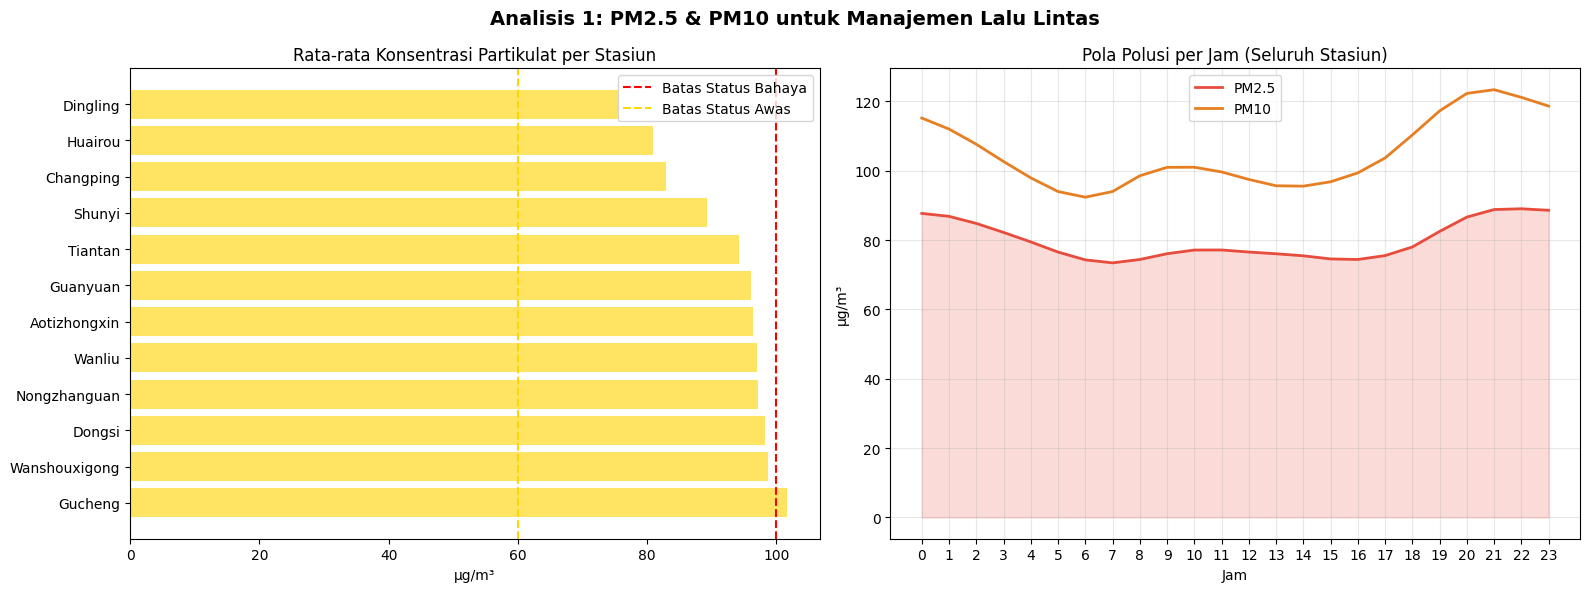


Grafik disimpan: chart/analisis_1_perencana_kota.png


In [48]:
# 1d. Visualisasi
# Buat grafik yang menunjukkan analisis 1: PM2.5 & PM10 untuk manajemen lalu lintas
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Analisis 1: PM2.5 & PM10 untuk Manajemen Lalu Lintas", fontsize=14, fontweight='bold')

# Buat grafik bar untuk menunjukkan status polusi per stasiun
# Warna akan digunakan untuk menentukan status polusi berdasarkan rata-rata konsentrasi partikulat
colors = ['#e74c3c' if '🔴' in z else '#F54F67' if '🟡' in z else '#FFE362' for z in station_pollution_sorted['Status']]
axes[0].barh(station_pollution_sorted.index, station_pollution_sorted['Avg_Particulate'], color=colors)
axes[0].set_title("Rata-rata Konsentrasi Partikulat per Stasiun")
axes[0].set_xlabel("µg/m³")
axes[0].axvline(x=100, color='red', linestyle='--', label='Batas Status Bahaya')
axes[0].axvline(x=60, color='gold', linestyle='--', label='Batas Status Awas')
axes[0].legend()

# Buat grafik untuk menunjukan pola polusi per jam
axes[1].plot(hourly_pollution.index, hourly_pollution['PM2.5'], label='PM2.5', color='#e74c3c', linewidth=2)
axes[1].plot(hourly_pollution.index, hourly_pollution['PM10'], label='PM10', color='#e67e22', linewidth=2)
axes[1].fill_between(hourly_pollution.index, hourly_pollution['PM2.5'], alpha=0.2, color='#e74c3c')
axes[1].set_title("Pola Polusi per Jam (Seluruh Stasiun)")
axes[1].set_xlabel("Jam")
axes[1].set_ylabel("µg/m³")
axes[1].set_xticks(range(0, 24))
axes[1].legend()
axes[1].grid(alpha=0.3)

# Menyimpan grafik ke dalam file
plt.tight_layout()
if not os.path.exists('chart'):
    os.makedirs('chart')
plt.savefig("chart/analisis_1_perencana_kota.png", dpi=150, bbox_inches='tight')
plt.show()
print("\nGrafik disimpan: chart/analisis_1_perencana_kota.png")


### Pertanyaan 2:

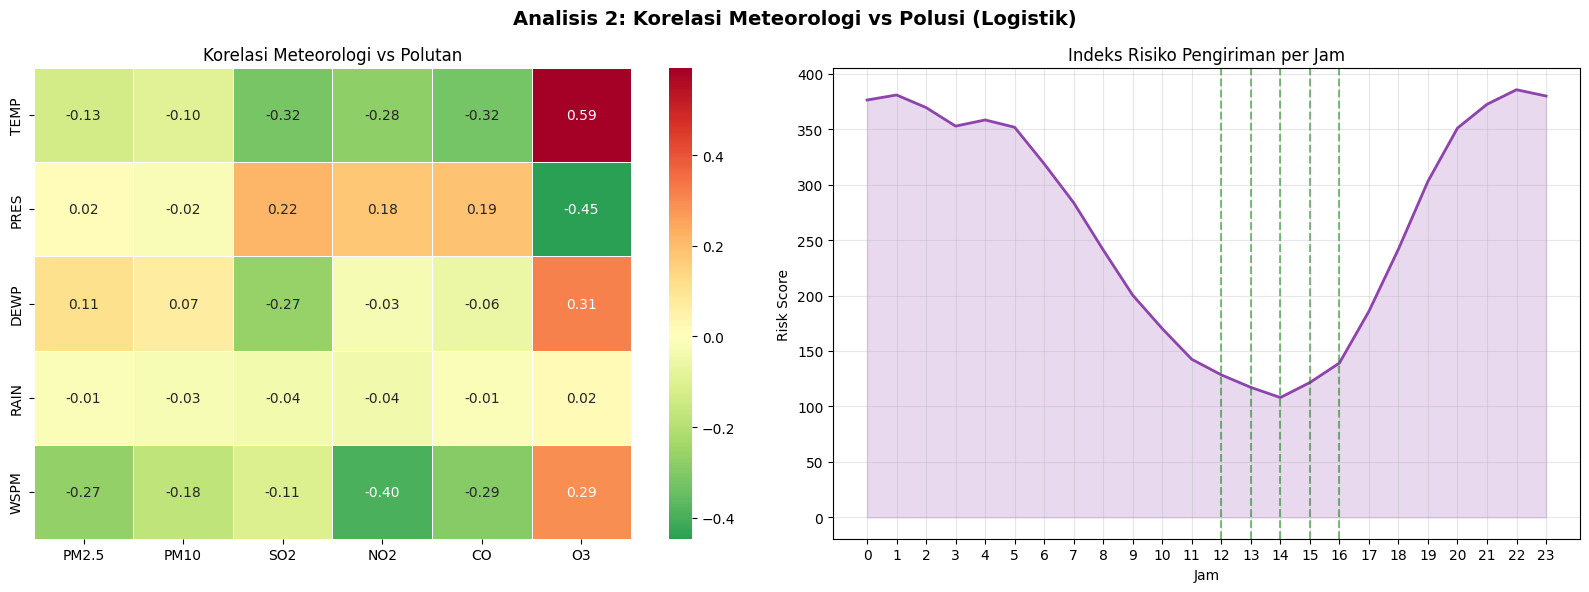


Grafik disimpan: chart/analisis_2_logistik.png


In [49]:
#2e. Visualisasi

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Analisis 2: Korelasi Meteorologi vs Polusi (Logistik)", fontsize=14, fontweight='bold')

# Heatmap korelasi
sns.heatmap(corr_meteo_vs_pollution, annot=True, fmt=".2f", cmap='RdYlGn_r',
center=0, ax=axes[0], linewidths=0.5)
axes[0].set_title("Korelasi Meteorologi vs Polutan")

# Risk score per jam
axes[1].plot(safe_hours.index, safe_hours.values, color='#8e44ad', linewidth=2)
axes[1].fill_between(safe_hours.index, safe_hours.values, alpha=0.2, color='#8e44ad')
axes[1].set_title("Indeks Risiko Pengiriman per Jam")
axes[1].set_xlabel("Jam")
axes[1].set_ylabel("Risk Score")
axes[1].set_xticks(range(0, 24))
axes[1].grid(alpha=0.3)
for h in safest:
    axes[1].axvline(x=h, color='green', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig("chart/analisis_2_logistik.png", dpi=150, bbox_inches='tight')
plt.show()
print("\nGrafik disimpan: chart/analisis_2_logistik.png")

### Pertanyaan 3:

C:\Users\melvi\AppData\Local\Temp\ipykernel_27392\1044943387.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(risk_sorted.index, rotation=45, ha='right')


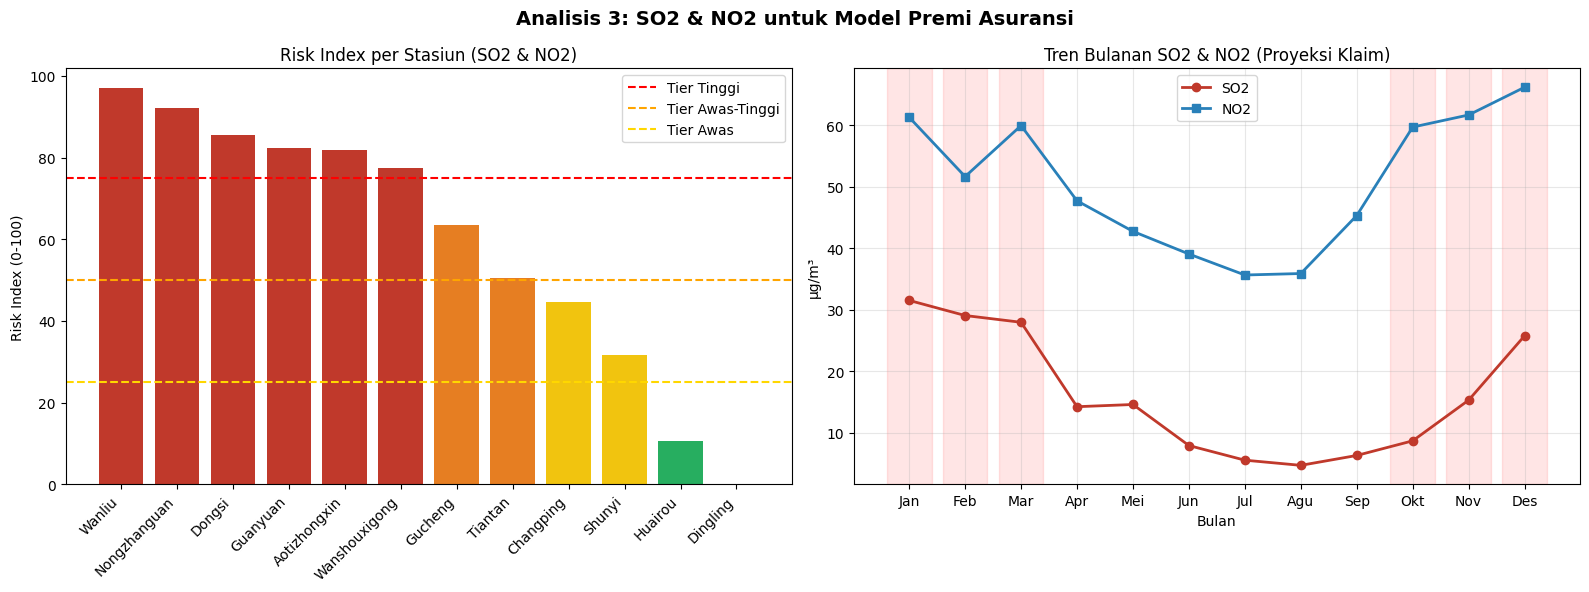


Grafik disimpan: chart/analisis_3_asuransi.png


In [50]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Analisis 3: SO2 & NO2 untuk Model Premi Asuransi", fontsize=14, fontweight='bold')

# Risk index & premi per stasiun
risk_sorted = risk_index.sort_values(ascending=False)
bar_colors = ['#c0392b' if s >= 75 else '#e67e22' if s >= 50
  else '#f1c40f' if s >= 25 else '#27ae60'
  for s in risk_sorted]
axes[0].bar(risk_sorted.index, risk_sorted.values, color=bar_colors)
axes[0].set_title("Risk Index per Stasiun (SO2 & NO2)")
axes[0].set_ylabel("Risk Index (0-100)")
axes[0].set_xticklabels(risk_sorted.index, rotation=45, ha='right')
axes[0].axhline(y=75, color='red',    linestyle='--', label='Tier Tinggi')
axes[0].axhline(y=50, color='orange', linestyle='--', label='Tier Awas-Tinggi')
axes[0].axhline(y=25, color='gold',   linestyle='--', label='Tier Awas')
axes[0].legend()

# Tren bulanan
axes[1].plot(monthly_trend.index, monthly_trend['SO2'], label='SO2', color='#c0392b', linewidth=2, marker='o')
axes[1].plot(monthly_trend.index, monthly_trend['NO2'], label='NO2', color='#2980b9', linewidth=2, marker='s')
axes[1].set_title("Tren Bulanan SO2 & NO2 (Proyeksi Klaim)")
axes[1].set_xlabel("Bulan")
axes[1].set_ylabel("µg/m³")
axes[1].set_xticks(range(1, 13))
axes[1].set_xticklabels([bulan[m] for m in range(1, 13)])
axes[1].legend()
axes[1].grid(alpha=0.3)
for m in high_risk_months:
    axes[1].axvspan(m - 0.4, m + 0.4, alpha=0.1, color='red')

plt.tight_layout()
plt.savefig("chart/analisis_3_asuransi.png", dpi=150, bbox_inches='tight')
plt.show()
print("\nGrafik disimpan: chart/analisis_3_asuransi.png")

**Insight:** <br>
**- Sebagai perencana kota** <br>
bagaimana cara mengintegrasikan data historis konsentrasi PM2.5 dan PM10 dari stasiun pemantauan ini ke dalam sistem manajemen lalu lintas untuk membatasi volume kendaraan di Status dengan tingkat polusi?<br>

*-* mengunakan perbandingan batas nyata rata-rata  PM2.5 PM10 dari data asli lalu dibandingkan dengan batas standart yang ditetapkan oleh WHO<br>

*-* data yang ada dibagi menjadi 3 kategori dengan detail : <br>
 - Avg_Particulate >= 100 = 🔴 Bahaya
 - Avg_Particulate >= 60   = 🟡 Awas
 - Avg_Particulate <= 60   = 🟢 Aman <br>

*-* konektivitas ke sistem pembatas kendaraan
 - 🔴 Bahaya = Ganjil-genap dan Batasi truk besar
 - 🟡 Awas   = Pantau real-time dan Siaga pengalihan
 - 🟢 Aman   = Normal, monitoring rutin


**- Sebagai manajer operasi** <br>
bagaimnana cara mengukur korelasi antara variabel meteorologi dan tingkat polusi udara untuk mengalihkan rute pengiriman guna menekan paparan polutan terhadap pekerja lapangan? <br>

*-* analisis korelasi variabel meteorologi terhadap konsentrasi polutan
mengidentifikasi hubungan signifikan dengan ambang batas koefisien korelasi di atas 0.3 untuk memetakan pengaruh cuaca terhadap kualitas udara


*-* detail arah hubungan :
 - ⏫positif⏫ = kenaikan variabel meteorologi diikuti kenaikan polutan
 - ⏬negatif⏬ = kenaikan variabel meteorologi membantu penurunan polutan

*-* perhitungan indeks risiko rute logistik per jam
formula Risk_Score menggunakan pembobotan polutan dengan detail :
 - PM2.5 40% 
 - PM10 20%
 - NO2 20%
 - CO 10%
 - SO2 10% <br>
 dibagi dengan variabel kecepatan angin (WSPM) sebagai faktor dispersi

*-* manajemen waktu pengiriman :
- Jam Aman = 5 periode waktu dengan skor risiko terendah untuk operasional armada
- Jam Berisiko = 5 periode waktu dengan skor risiko tertinggi yang harus dihindari
- klasifikasi keamanan wilayah berdasarkan stasiun pemantauan
- ranking stasiun disusun dari tingkat risiko terendah hingga tertinggi untuk menentukan prioritas rute pengiriman Anda <br>

**- Sebagai aktuaris asuransi kesehatan** <br>
menganalisis fluktuasi senyawa SO2 dan NO2 dari kumpulan data ini untuk memodelkan potensi lonjakan klaim penyakit pernapasan dan merancang struktur premi berdasarkan lokasi pemukiman nasabah? <br>

*-* analisis statistik deskriptif dan deteksi lonjakan konsentrasi SO2 serta NO2
*-* sistem mengidentifikasi lonjakan melalui perhitungan nilai di atas rata-rata ditambah dua kali standar deviasi guna menentukan frekuensi anomali udara pada setiap stasiun <br>
*-* pemodelan struktur premi asuransi kesehatan berbasis risiko lokasi <br>
*-* perhitungan Risk Index menggunakan normalisasi data SO2 dengan bobot 60 persen dan NO2 dengan bobot 40 persen dalam rentang skala 0 hingga 100 <br>
*-* pembagian kategori premi bulanan : <br>
 - Tier Tinggi = Skor >= 75 dengan nominal Rp 1.000.000
 - Tier Awas-Tinggi = Skor >= 50 dengan nominal Rp 750.000
 - Tier Awas = Skor >= 25 dengan nominal Rp 600.000
 - Tier Rendah = Skor < 25 dengan nominal Rp 500.000 <br> 
*-* pemetaan tren bulanan untuk menentukan kebutuhan cadangan klaim asuransi <br>
*-* mengidentifikasi bulan dengan risiko klaim tinggi melalui deteksi konsentrasi polutan yang melampaui rata-rata tahunan <br>
*-* data tersebut menjadi landasan dalam mengatur alokasi dana cadangan klaim pada periode waktu yang teridentifikasi berisiko

## Analisis Lanjutan (Opsional)

1 : RFM-style Analysis: <br>
(Recency spike, Frequency lonjakan, Magnitude polutan) <br>
2 : Clustering Manual Grouping: <br>
(Pengelompokan stasiun berdasarkan tingkat polusi) <br>
3 : Geospatial Analysis: : <br>
(Peta distribusi polusi per stasiun — Folium) <br>
4 : Clustering Binning: <br>
(Kategorisasi level PM2.5 / AQI ke interval) <br>

In [51]:
warnings.filterwarnings('ignore')

# Output directory
OUTPUT_DIR = "./output_analisis_lanjutan"
PLOT_DIR   = os.path.join(OUTPUT_DIR, "plots")
MAP_DIR    = os.path.join(OUTPUT_DIR, "maps")
os.makedirs(PLOT_DIR, exist_ok=True)
os.makedirs(MAP_DIR,  exist_ok=True)

plt.rcParams.update({
    'figure.dpi'       : 150,
    'axes.spines.top'  : False,
    'axes.spines.right': False,
    'font.size'        : 10,
})

# Koordinat geografis 12 stasiun Beijing
STATION_COORDS = {
    'Aotizhongxin' : (39.9824, 116.3976),
    'Changping'    : (40.2149, 116.2310),
    'Dingling'     : (40.2900, 116.2200),
    'Dongsi'       : (39.9290, 116.4170),
    'Guanyuan'     : (39.9290, 116.3390),
    'Gucheng'      : (39.9140, 116.1840),
    'Huairou'      : (40.3280, 116.6280),
    'Nongzhanguan' : (39.9370, 116.4610),
    'Shunyi'       : (40.1270, 116.6550),
    'Tiantan'      : (39.8860, 116.4070),
    'Wanliu'       : (39.9870, 116.2870),
    'Wanshouxigong': (39.8780, 116.3520),
}


# Opsional 1 — RFM-STYLE ANALYSIS
* Recency  : Hari sejak terakhir kali terjadi spike polutan
* Frequency: Jumlah hari dalam setahun terjadi spike PM2.5
* Magnitude: Rata-rata konsentrasi PM2.5 saat spike


# Opsional 2 — CLUSTERING MANUAL GROUPING
* Pengelompokan stasiun berdasarkan aturan domain / bisnis


  Hasil Manual Grouping per Stasiun:

  Stasiun                PM2.5     NO2     SO2  Klaster
  ───────────────────────────────────────────────────────────────────────────
  Dongsi                  86.1    54.0    18.5  Klaster B — Polusi Sedang (Urban Menengah)
  Nongzhanguan            85.1    58.1    18.8  Klaster B — Polusi Sedang (Urban Menengah)
  Wanshouxigong           85.1    55.5    17.4  Klaster B — Polusi Sedang (Urban Menengah)
  Gucheng                 84.1    55.8    15.7  Klaster B — Polusi Sedang (Urban Menengah)
  Wanliu                  83.5    65.7    18.4  Klaster A — Polusi Tinggi (Urban Padat)
  Guanyuan                82.9    58.1    17.6  Klaster B — Polusi Sedang (Urban Menengah)
  Aotizhongxin            82.5    59.1    17.5  Klaster B — Polusi Sedang (Urban Menengah)
  Tiantan                 82.0    53.3    14.5  Klaster B — Polusi Sedang (Urban Menengah)
  Shunyi                  79.4    44.1    13.4  Klaster C — Polusi Rendah-Sedang (Suburban)
  Changpin

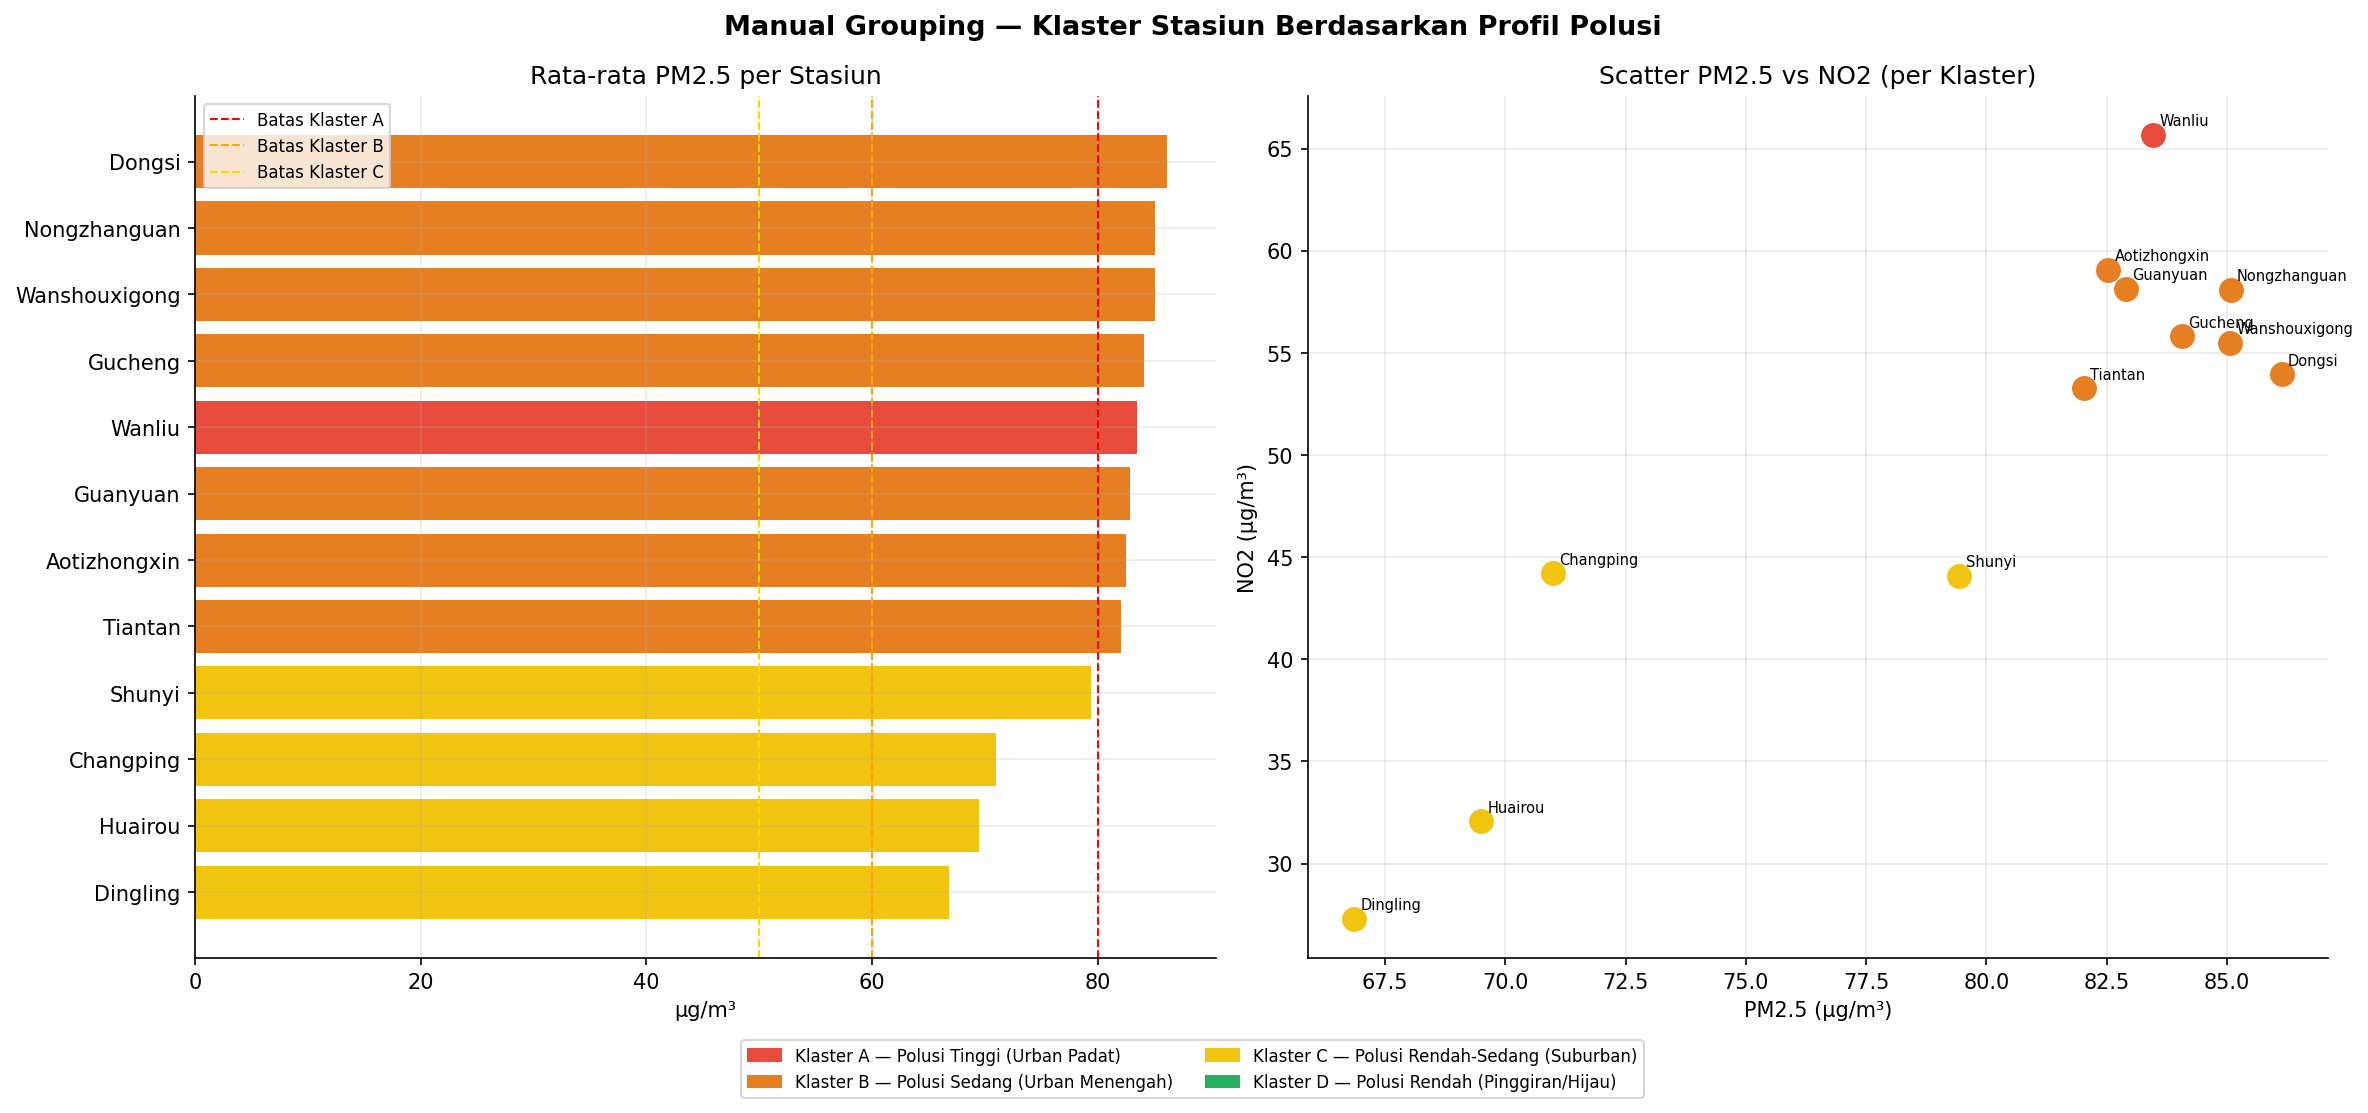


  Plot disimpan: ./output_analisis_lanjutan\plots\M2_manual_grouping.png


In [58]:
"""
Mengelompokkan stasiun ke dalam klaster berdasarkan kriteria domain / aturan bisnis:
  Profil PM2.5 (mean) × Profil NO2 (mean) × Lokasi (urban/suburban/rural)
"""
# Profil rata-rata per stasiun
# Membuatkan dataframe yang berisi profil rata-rata per stasiun
profile = df_all.groupby('station').agg(
    PM25_mean = ('PM2.5', 'mean'),  # Nilai rata-rata PM2.5 per stasiun
    PM10_mean = ('PM10', 'mean'),  # Nilai rata-rata PM10 per stasiun
    NO2_mean  = ('NO2',  'mean'),  # Nilai rata-rata NO2 per stasiun
    SO2_mean  = ('SO2',  'mean'),  # Nilai rata-rata SO2 per stasiun
    CO_mean   = ('CO',   'mean'),  # Nilai rata-rata CO per stasiun
    O3_mean   = ('O3',   'mean'),  # Nilai rata-rata O3 per stasiun
).round(2)

# Aturan pengelompokan (domain knowledge)
# Berdasarkan WHO annual guideline PM2.5 = 5 µg/m³
# Fungsi untuk mengelompokkan stasiun berdasarkan kriteria domain / aturan bisnis
def assign_group(row):
    """
    Mengelompokkan stasiun berdasarkan kriteria domain / aturan bisnis
    """
    pm25 = row['PM25_mean']
    no2  = row['NO2_mean']
    if pm25 > 80 and no2 > 60:
        # Klaster A — Polusi Tinggi (Urban Padat)
        return 'Klaster A — Polusi Tinggi (Urban Padat)'
    elif pm25 > 60 and no2 > 45:
        # Klaster B — Polusi Sedang (Urban Menengah)
        return 'Klaster B — Polusi Sedang (Urban Menengah)'
    elif pm25 > 50:
        # Klaster C — Polusi Rendah-Sedang (Suburban)
        return 'Klaster C — Polusi Rendah-Sedang (Suburban)'
    else:
        # Klaster D — Polusi Rendah (Pinggiran/Hijau)
        return 'Klaster D — Polusi Rendah (Pinggiran/Hijau)'

# Mengelompokkan stasiun berdasarkan kriteria domain / aturan bisnis
profile['Klaster'] = profile.apply(assign_group, axis=1)
profile_sorted = profile.sort_values('PM25_mean', ascending=False)

print("\n  Hasil Manual Grouping per Stasiun:")
print(f"\n  {'Stasiun':<20} {'PM2.5':>7} {'NO2':>7} {'SO2':>7}  Klaster")
print("  " + "─" * 75)
for st, row in profile_sorted.iterrows():
    print(f"  {st:<20} {row['PM25_mean']:>7.1f} {row['NO2_mean']:>7.1f} "
  f"{row['SO2_mean']:>7.1f}  {row['Klaster']}")

print("\n  Ringkasan per Klaster:")
# Membuatkan ringkasan per klaster
for klaster, grp in profile.groupby('Klaster'):
    members = grp.index.tolist()
    print(f"\n  {klaster}")
    print(f"    Stasiun : {', '.join(members)}")
    print(f"    PM2.5   : {grp['PM25_mean'].mean():.1f} µg/m³")
    print(f"    NO2     : {grp['NO2_mean'].mean():.1f} µg/m³")

# Visualisasi
klaster_colors = {
    'Klaster A — Polusi Tinggi (Urban Padat)'      : '#e74c3c',
    'Klaster B — Polusi Sedang (Urban Menengah)'   : '#e67e22',
    'Klaster C — Polusi Rendah-Sedang (Suburban)'  : '#f1c40f',
    'Klaster D — Polusi Rendah (Pinggiran/Hijau)'  : '#27ae60',
}
colors = [klaster_colors[profile_sorted.loc[s, 'Klaster']]
for s in profile_sorted.index]

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle("Manual Grouping — Klaster Stasiun Berdasarkan Profil Polusi",
     fontsize=13, fontweight='bold')

# Bar PM2.5
axes[0].barh(profile_sorted.index, profile_sorted['PM25_mean'], color=colors)
axes[0].set_title("Rata-rata PM2.5 per Stasiun")
axes[0].set_xlabel("µg/m³")
axes[0].axvline(x=80, color='red',    linestyle='--',linewidth=1, label='Batas Klaster A')
axes[0].axvline(x=60, color='orange', linestyle='--',linewidth=1, label='Batas Klaster B')
axes[0].axvline(x=50, color='gold',   linestyle='--',linewidth=1, label='Batas Klaster C')
axes[0].legend(fontsize=8)
axes[0].invert_yaxis()
axes[0].grid(alpha=0.25)

# Scatter PM2.5 vs NO2
for st, row in profile.iterrows():
    c = klaster_colors[row['Klaster']]
    axes[1].scatter(row['PM25_mean'], row['NO2_mean'], color=c, s=120, zorder=3)
    axes[1].annotate(st, (row['PM25_mean'], row['NO2_mean']),
            fontsize=7, ha='left', va='bottom',
            xytext=(3, 3), textcoords='offset points')
axes[1].set_xlabel("PM2.5 (µg/m³)")
axes[1].set_ylabel("NO2 (µg/m³)")
axes[1].set_title("Scatter PM2.5 vs NO2 (per Klaster)")
axes[1].grid(alpha=0.25)

handles = [mpatches.Patch(color=c, label=l) for l, c in klaster_colors.items()]
fig.legend(handles=handles, loc='lower center', ncol=2, fontsize=8,
   bbox_to_anchor=(0.5, -0.06))

plt.tight_layout()
path = os.path.join(PLOT_DIR, "M2_manual_grouping.png")
plt.savefig(path, bbox_inches='tight')
plt.show()
print(f"\n  Plot disimpan: {path}")


# Opsional 3 — GEOSPATIAL ANALYSIS
* Peta interaktif distribusi polusi per stasiun (Folium)


  Peta interaktif disimpan: ./output_analisis_lanjutan\maps\M3_geospatial_pm25.html
     Buka file .html di browser untuk melihat peta


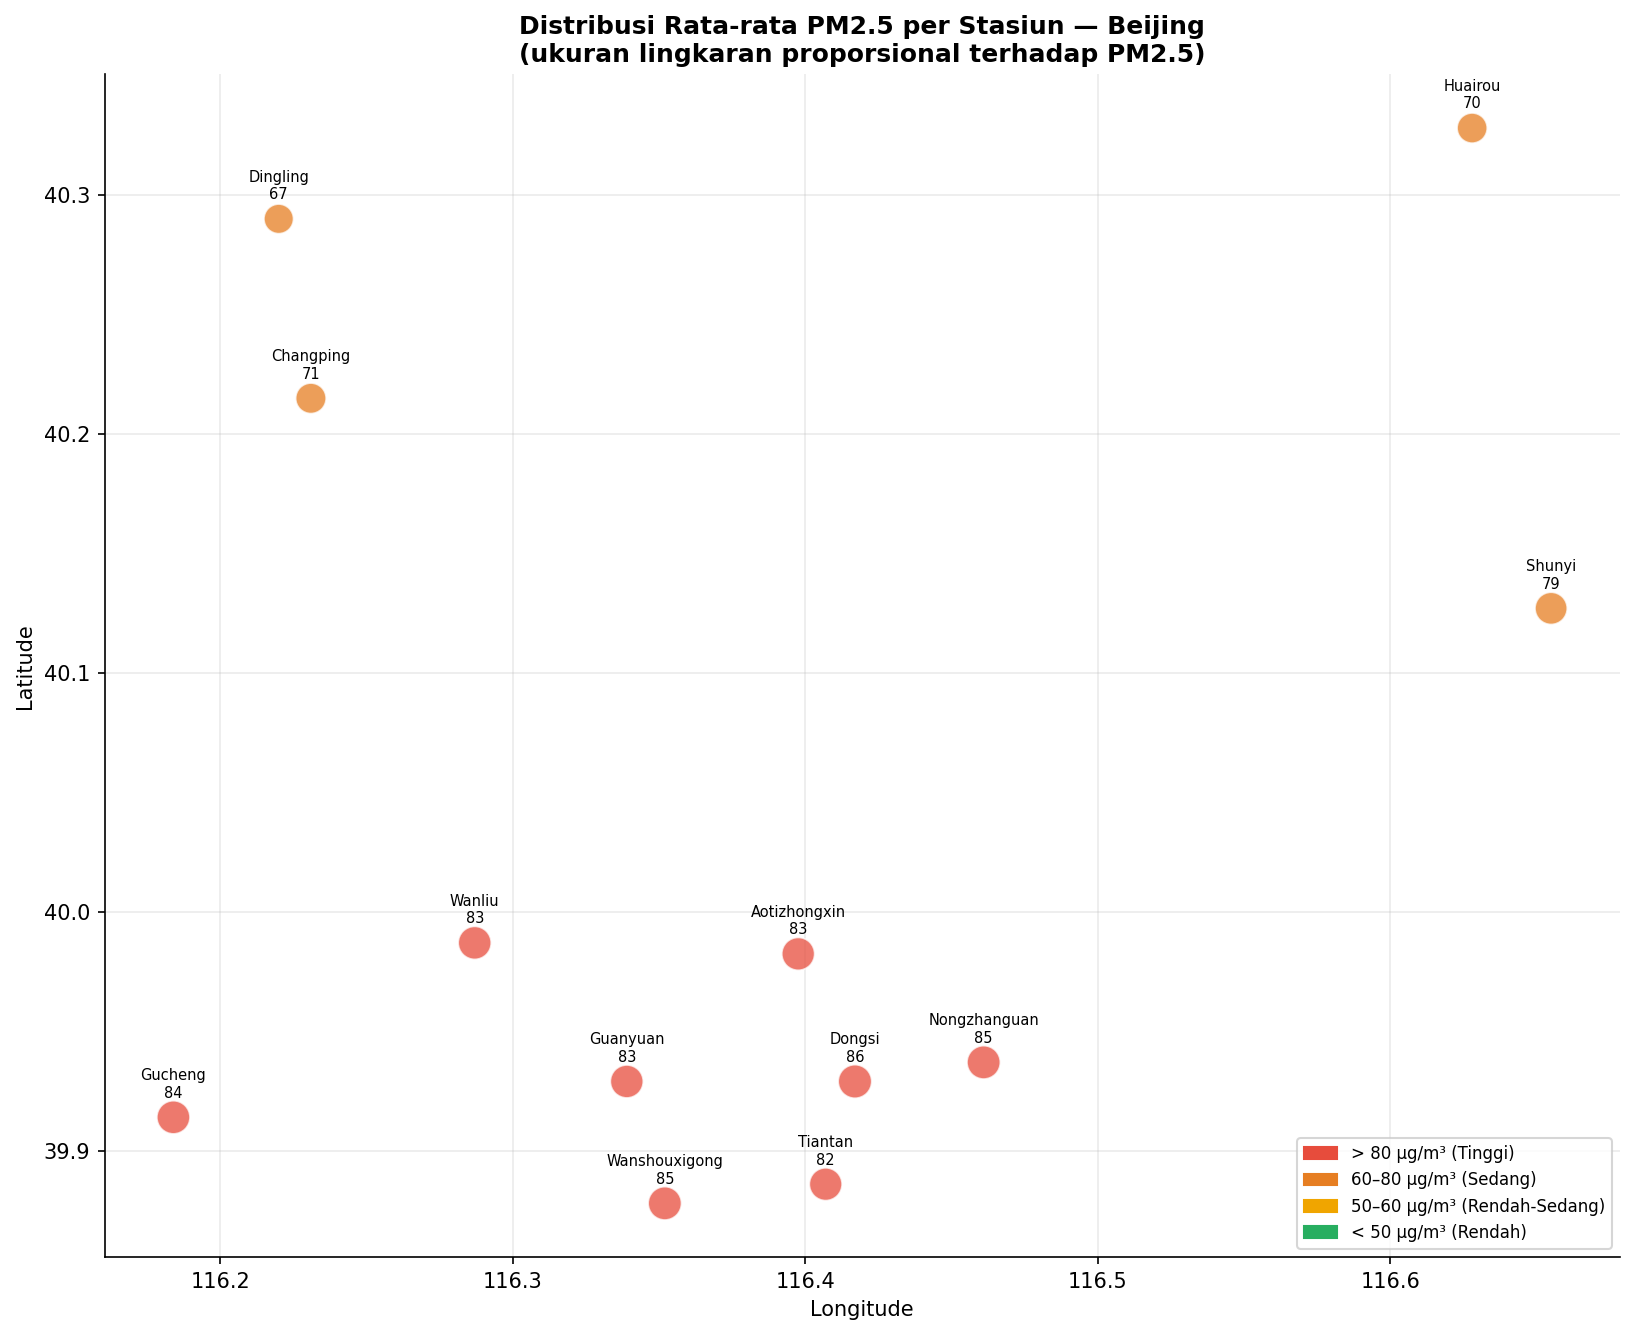

  Plot static disimpan: ./output_analisis_lanjutan\plots\M3_geospatial_static.png


In [59]:
# Fungsi untuk membuat peta interaktif berbasis data stasiun
# dengan fitur:
# 1. Marker per stasiun + popup info polusi
# 2. Heatmap distribusi PM2.5
# 3. Circle radius proporsional terhadap rata-rata PM2.5

def modul3_geospatial(df, coords):
    """
    Membuat peta interaktif berbasis data stasiun
    dengan fitur:
    1. Marker per stasiun + popup info polusi
    2. Heatmap distribusi PM2.5
    3. Circle radius proporsional terhadap rata-rata PM2.5
    """
    # Profil rata-rata per stasiun
    station_avg = df.groupby('station').agg(
        PM25=('PM2.5', 'mean'),
        PM10=('PM10', 'mean'),
        NO2=('NO2', 'mean'),
        SO2=('SO2', 'mean'),
        CO=('CO', 'mean'),
        O3=('O3', 'mean'),
    ).round(2)

    # Warna marker berdasarkan PM2.5
    def marker_color(pm25):
        if pm25 > 80:
            return 'red'
        elif pm25 > 60:
            return 'orange'
        elif pm25 > 50:
            return 'beige'
        else:
            return 'green'

    # Buat peta dasar
    center = [39.95, 116.39]
    m = folium.Map(location=center, zoom_start=10,
           tiles='CartoDBpositron')

    # Layer 1: Circle marker proporsional
    for station, row in station_avg.iterrows():
        if station not in coords:
            continue
        lat, lon = coords[station]
        color    = marker_color(row['PM25'])
        radius   = row['PM25'] * 0.4  # proporsional

        folium.CircleMarker(
            location=[lat, lon],
            radius=radius,
            color=color,
            fill=True,
            fill_color=color,
            fill_opacity=0.45,
            weight=1.5,
        ).add_to(m)

        # Layer 2: Marker dengan popup detail
        popup_html = f"""
        <div style="font-family:Arial; font-size:12px; width:200px">
          <b style="font-size:14px">{station}</b><hr>
          <table>
            <tr><td>PM2.5</td><td><b>{row['PM25']} µg/m³</b></td></tr>
            <tr><td>PM10 </td><td>{row['PM10']} µg/m³</td></tr>
            <tr><td>NO2  </td><td>{row['NO2']} µg/m³</td></tr>
            <tr><td>SO2  </td><td>{row['SO2']} µg/m³</td></tr>
            <tr><td>CO   </td><td>{row['CO']} µg/m³</td></tr>
            <tr><td>O3   </td><td>{row['O3']} µg/m³</td></tr>
          </table>
        </div>"""
        folium.Marker(
            location=[lat, lon],
            popup=folium.Popup(popup_html, max_width=220),
            tooltip=f"{station} | PM2.5: {row['PM25']:.0f} µg/m³",
            icon=folium.Icon(color=color, icon='cloud', prefix='fa'),
        ).add_to(m)

    # Layer 3: Heatmap PM2.5
    heat_data = [
        [coords[st][0], coords[st][1], station_avg.loc[st, 'PM25']]
        for st in station_avg.index if st in coords
    ]
    HeatMap(heat_data, radius=40, blur=25, min_opacity=0.3,
          gradient={0.4:'blue', 0.65:'lime', 0.85:'orange', 1.0:'red'}
    ).add_to(m)

    # Legend manual
    legend_html = """
    <div style="position:fixed; bottom:30px; left:30px; z-index:1000;
    background:white; padding:12px; border-radius:8px;
    border:1px solid #ccc; font-size:12px; font-family:Arial">
      <b>Tingkat PM2.5</b><br>
      <span style="color:#e74c3c">●</span> &gt; 80 µg/m³ — Polusi Tinggi<br>
      <span style="color:#e67e22">●</span> 60–80 µg/m³ — Polusi Sedang<br>
      <span style="color:#f0a500">●</span> 50–60 µg/m³ — Polusi Rendah-Sedang<br>
      <span style="color:#27ae60">●</span> &lt; 50 µg/m³ — Polusi Rendah
    </div>"""
    m.get_root().html.add_child(folium.Element(legend_html))

    # Simpan peta
    map_path = os.path.join(MAP_DIR, "M3_geospatial_pm25.html")
    m.save(map_path)
    print(f"\n  Peta interaktif disimpan: {map_path}")
    print("     Buka file .html di browser untuk melihat peta")

    # Static plot sebagai ringkasan
    lats   = [coords[s][0] for s in station_avg.index if s in coords]
    lons   = [coords[s][1] for s in station_avg.index if s in coords]
    pm25s  = [station_avg.loc[s, 'PM25'] for s in station_avg.index if s in coords]
    names  = [s for s in station_avg.index if s in coords]
    colors = [marker_color(p) for p in pm25s]
    color_fix = {'red':'#e74c3c','orange':'#e67e22','beige':'#f0a500','green':'#27ae60'}

    fig, ax = plt.subplots(figsize=(11, 9))
    sc = ax.scatter(lons, lats,
        s=[p * 3 for p in pm25s],
        c=[color_fix[c] for c in colors],
        alpha=0.75, zorder=3, edgecolors='white', linewidths=0.8)
    for i, name in enumerate(names):
        ax.annotate(f"{name}\n{pm25s[i]:.0f}", (lons[i], lats[i]),
              fontsize=7, ha='center', va='bottom',
              xytext=(0, 8), textcoords='offset points')

    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.set_title("Distribusi Rata-rata PM2.5 per Stasiun — Beijing\n(ukuran lingkaran proporsional terhadap PM2.5)",
          fontsize=12, fontweight='bold')
    ax.grid(alpha=0.25)

    handles = [
        mpatches.Patch(color='#e74c3c', label='> 80 µg/m³ (Tinggi)'),
        mpatches.Patch(color='#e67e22', label='60–80 µg/m³ (Sedang)'),
        mpatches.Patch(color='#f0a500', label='50–60 µg/m³ (Rendah-Sedang)'),
        mpatches.Patch(color='#27ae60', label='< 50 µg/m³ (Rendah)'),
    ]
    ax.legend(handles=handles, loc='lower right', fontsize=8)

    plt.tight_layout()
    static_path = os.path.join(PLOT_DIR, "M3_geospatial_static.png")
    plt.savefig(static_path, bbox_inches='tight')
    plt.show()
    print(f"  Plot static disimpan: {static_path}")

    return m

geo_map = modul3_geospatial(df_all, STATION_COORDS)



# Opsional 4 — CLUSTERING BINNING
* Kategorisasi level PM2.5 berdasarkan interval AQI



════════════════════════════════════════════════════════════
4: Clustering Binning
  Kategorisasi Level PM2.5 berdasarkan AQI Interval
════════════════════════════════════════════════════════════

  Distribusi Kategori AQI (Seluruh Dataset):

  Kategori                   Jumlah   Persentase
  ────────────────────────────────────────────────
  Good                       63,928       15.19%
  Moderate                   93,055       22.12%
  Sensitive Groups           54,482       12.95%
  Unhealthy                 145,447       34.57%
  Very Unhealthy             44,958       10.68%
  Hazardous                  18,898        4.49%

  % Kategori AQI per Stasiun (5 kolom pertama):
AQI_Category   Good  Moderate  Sensitive Groups  Unhealthy
station                                                   
Aotizhongxin   13.4      22.1              13.0       35.5
Changping      15.8      26.6              13.1       31.9
Dingling       22.6      23.7              12.6       29.2
Dongsi         14.

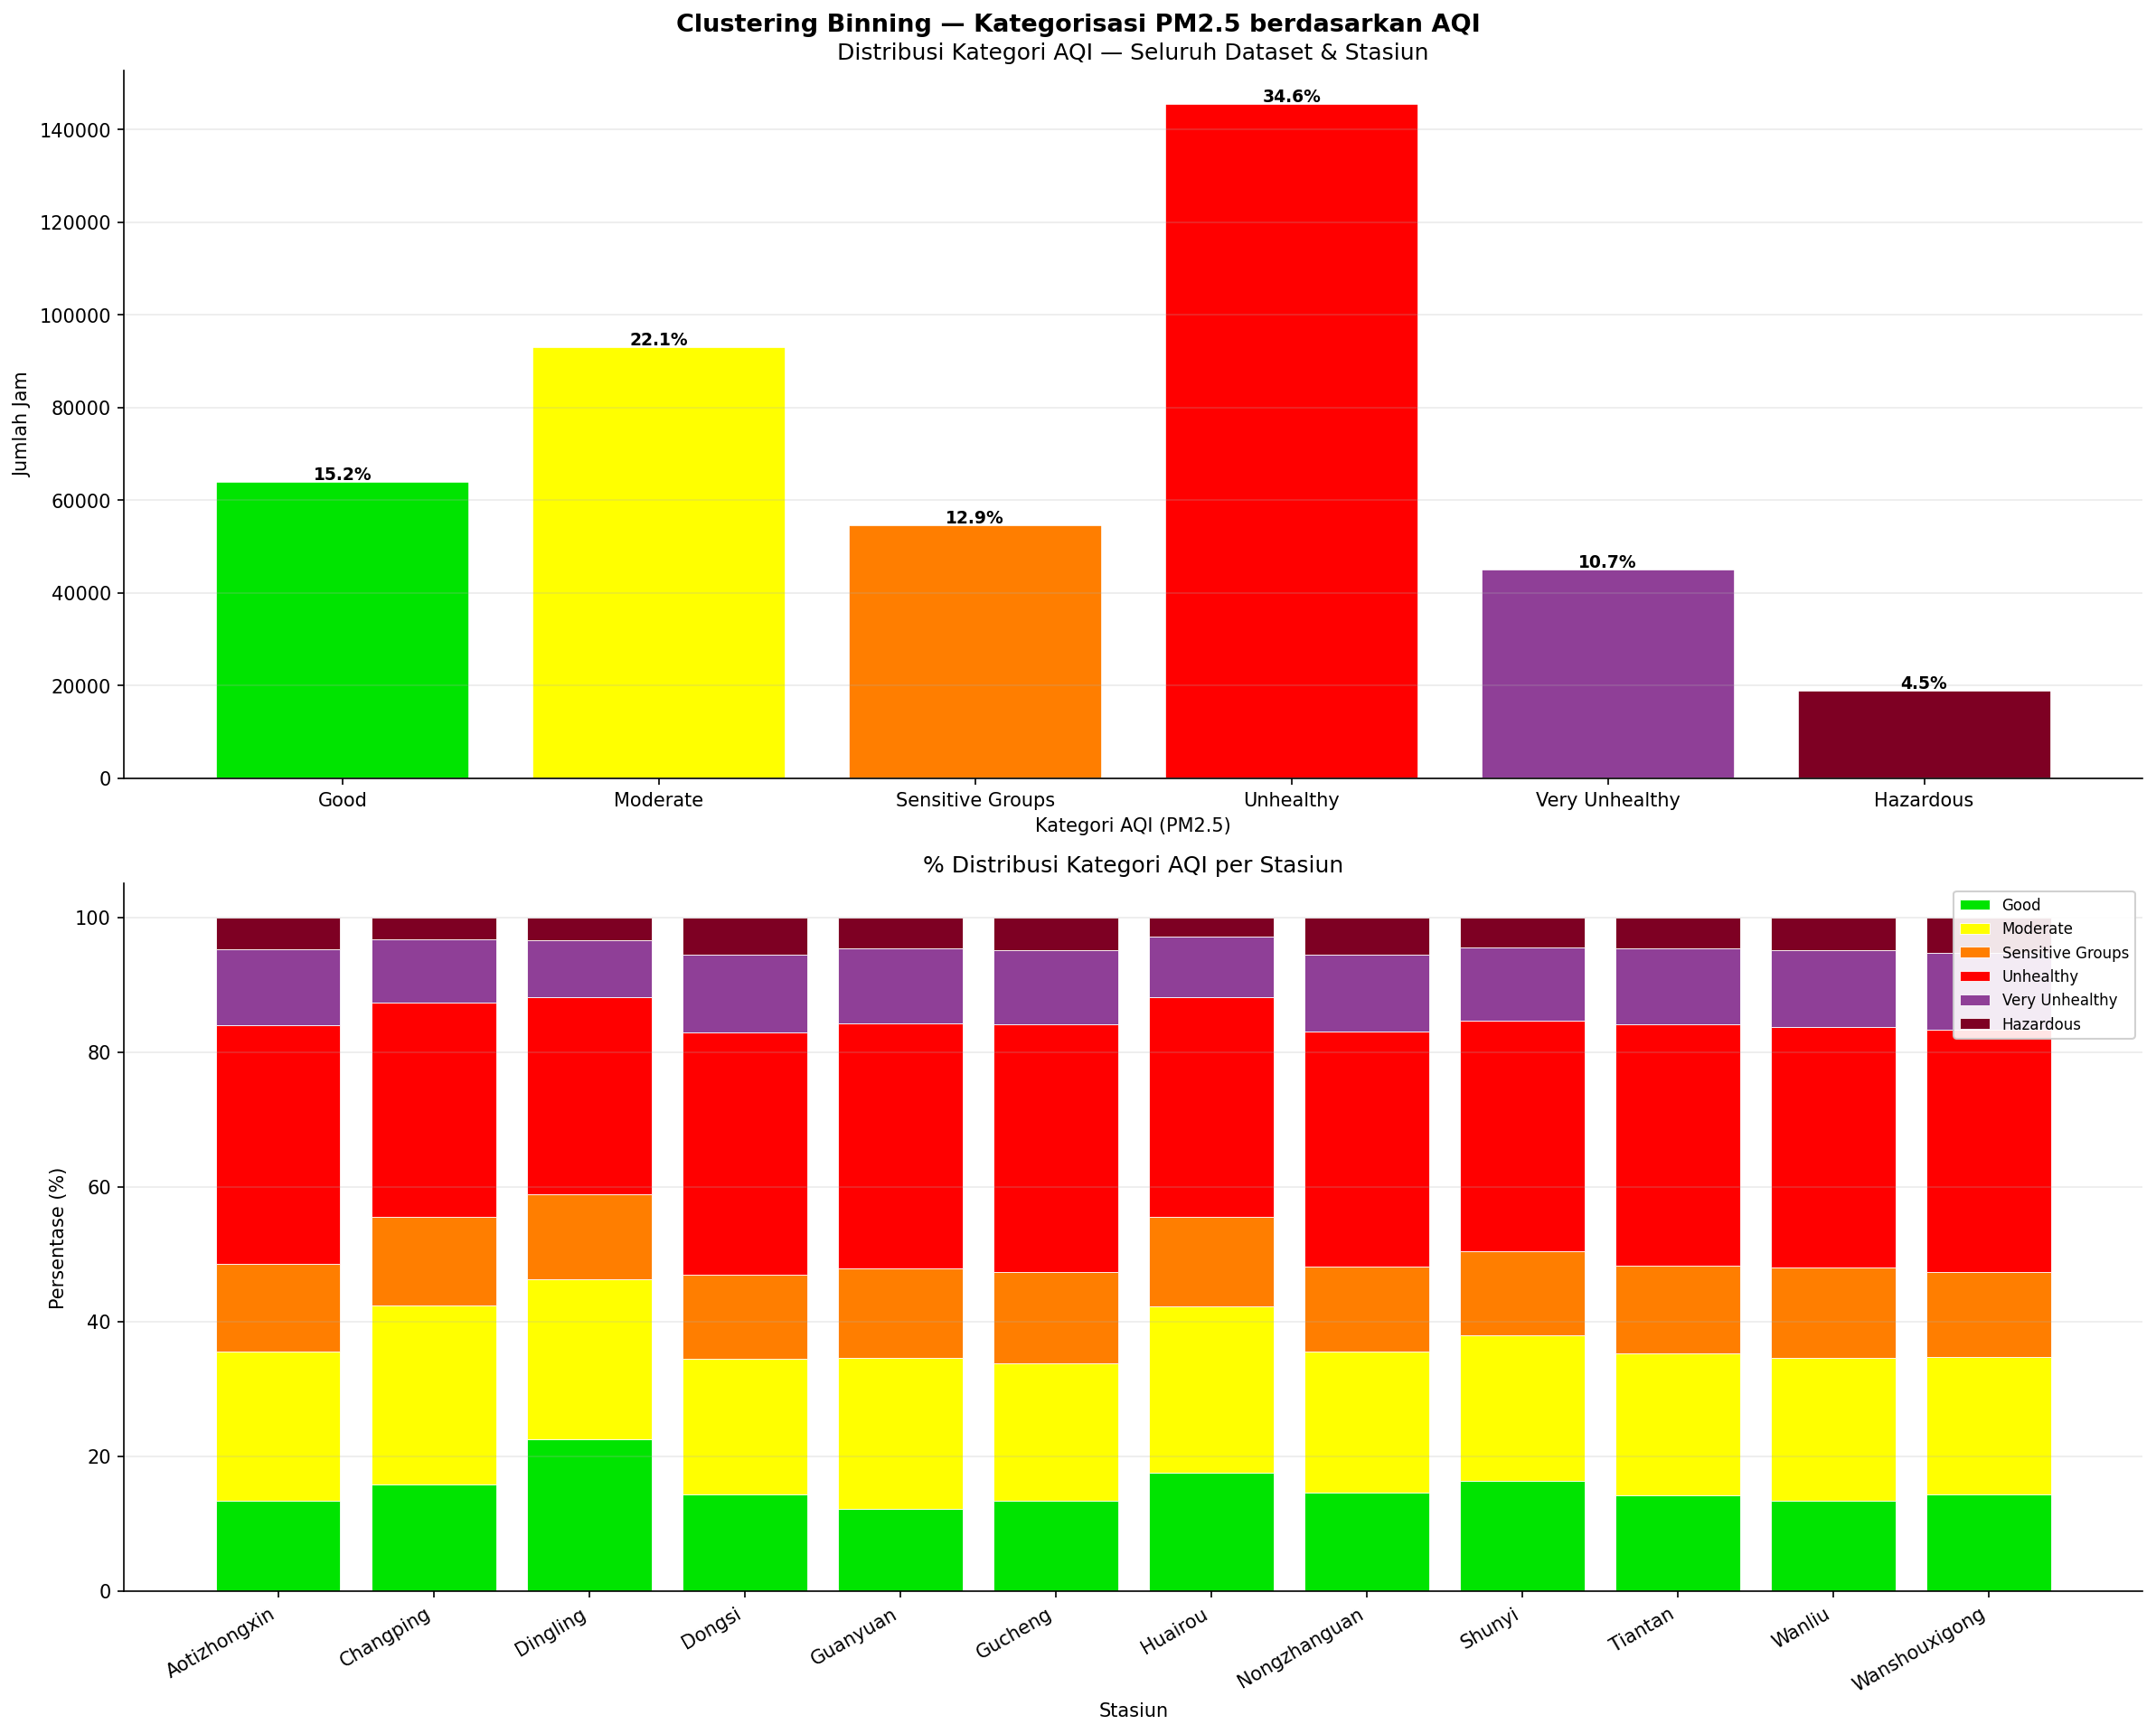


  Plot disimpan: ./output_analisis_lanjutan\plots\M4_binning_aqi.png


In [55]:
print("\n" + "═" * 60)
print("4: Clustering Binning")
print("  Kategorisasi Level PM2.5 berdasarkan AQI Interval")
print("═" * 60)

def modul4_binning(df):
    """
    Membagi konsentrasi PM2.5 ke dalam 6 kategori AQI
    menggunakan pd.cut() (binning), tanpa ML.

    Standar AQI US-EPA untuk PM2.5 (µg/m³ per 24 jam):
      0 – 12.0     : Good
      12.1 – 35.4  : Moderate
      35.5 – 55.4  : Unhealthy for Sensitive Groups
      55.5 – 150.4 : Unhealthy
      150.5 – 250.4: Very Unhealthy
      250.5+       : Hazardous
    """
    bins   = [0, 12, 35.4, 55.4, 150.4, 250.4, float('inf')]
    labels = ['Good', 'Moderate', 'Sensitive Groups',
  'Unhealthy', 'Very Unhealthy', 'Hazardous']
    aqi_colors = {
        'Good': '#00e400',
        'Moderate'        : '#ffff00',
        'Sensitive Groups': '#ff7e00',
        'Unhealthy'       : '#ff0000',
        'Very Unhealthy'  : '#8f3f97',
        'Hazardous'       : '#7e0023',
    }

    df = df.copy()
    df['AQI_Category'] = pd.cut(df['PM2.5'], bins=bins, labels=labels, right=True)

    # Distribusi global
    global_dist = df['AQI_Category'].value_counts().reindex(labels)
    global_pct  = (global_dist / global_dist.sum() * 100).round(2)

    print("\n  Distribusi Kategori AQI (Seluruh Dataset):")
    print(f"\n  {'Kategori':<22} {'Jumlah':>10} {'Persentase':>12}")
    print("  " + "─" * 48)
    for cat in labels:
        print(f"  {cat:<22} {global_dist[cat]:>10,} {global_pct[cat]:>11.2f}%")

    # Distribusi per stasiun
    station_dist = (
        df.groupby(['station', 'AQI_Category'], observed=True)
          .size()
          .unstack(fill_value=0)
          .reindex(columns=labels, fill_value=0)
    )
    station_pct = station_dist.div(station_dist.sum(axis=1), axis=0) * 100

    print("\n  % Kategori AQI per Stasiun (5 kolom pertama):")
    print(station_pct[labels[:4]].round(1).to_string())

    # Visualisasi
    fig, axes = plt.subplots(2, 1, figsize=(16, 13))
    fig.suptitle("Clustering Binning — Kategorisasi PM2.5 berdasarkan AQI",
     fontsize=13, fontweight='bold')

    # Plot 1: Distribusi global (pie + bar)
    bar_colors = [aqi_colors[l] for l in labels]
    axes[0].bar(labels, global_dist.values, color=bar_colors,
    edgecolor='white', linewidth=0.8)
    axes[0].set_title("Distribusi Kategori AQI — Seluruh Dataset & Stasiun")
    axes[0].set_ylabel("Jumlah Jam")
    axes[0].set_xlabel("Kategori AQI (PM2.5)")
    for i, (val, pct) in enumerate(zip(global_dist.values, global_pct.values)):
        axes[0].text(i, val + 500, f"{pct:.1f}%", ha='center', fontsize=9, fontweight='bold')
    axes[0].grid(axis='y', alpha=0.25)

    # Plot 2: Stacked bar per stasiun
    bottom = np.zeros(len(station_pct))
    for cat in labels:
        vals = station_pct[cat].values
        axes[1].bar(station_pct.index, vals, bottom=bottom,
        color=aqi_colors[cat], label=cat,
        edgecolor='white', linewidth=0.4)
        bottom += vals
    axes[1].set_title("% Distribusi Kategori AQI per Stasiun")
    axes[1].set_ylabel("Persentase (%)")
    axes[1].set_xlabel("Stasiun")
    axes[1].set_xticklabels(station_pct.index, rotation=30, ha='right')
    axes[1].legend(loc='upper right', fontsize=8, framealpha=0.9)
    axes[1].grid(axis='y', alpha=0.25)

    plt.tight_layout()
    path = os.path.join(PLOT_DIR, "M4_binning_aqi.png")
    plt.savefig(path, bbox_inches='tight')
    plt.show()
    print(f"\n  Plot disimpan: {path}")

    return df, station_pct


df_binned, aqi_by_station = modul4_binning(df_all)

## Conclusion

- Conclusion Pertanyaan 1
Bagaimana cara mengintegrasikan data historis konsentrasi PM2.5 dan PM10 ke dalam sistem manajemen lalu lintas untuk membatasi volume kendaraan di zona dengan tingkat polusi tinggi?<br>

Berdasarkan analisis klasifikasi zona polusi menggunakan rata-rata PM2.5 dan PM10 dari seluruh stasiun pemantauan (Maret 2013 – Februari 2017), ditemukan bahwa:<br>

- Gucheng adalah satu-satunya stasiun yang masuk 🔴 Zona Merah dengan rata-rata partikulat 101.67 µg/m³, melampaui ambang batas kritis (≥ 100 µg/m³).<br>
- Stasiun ini memerlukan kebijakan pembatasan kendaraan paling ketat, seperti sistem ganjil-genap dan larangan truk besar.<br>
- 11 stasiun lainnya (Wanshouxigong, Dongsi, Nongzhanguan, Wanliu, Aotizhongxin, Guanyuan, Tiantan, Shunyi, Changping, Huairou, Dingling) berada di 🟡 Zona Kuning (60–100 µg/m³), yang memerlukan pemantauan real-time dan kesiagaan pengalihan lalu lintas.<br>
- Analisis pola jam menunjukkan bahwa polusi paling tinggi terjadi pada jam 20.00 – 01.00 dini hari, yang merupakan waktu operasional kendaraan berat dan truk logistik. Pembatasan kendaraan berat pada jam-jam ini dapat menjadi intervensi paling efektif.<br>

Rekomendasi: Integrasikan data PM2.5 dan PM10 secara real-time ke sistem manajemen lalu lintas dengan ambang batas otomatis — ketika konsentrasi partikulat melebihi 100 µg/m³, sistem secara otomatis mengaktifkan kebijakan pembatasan kendaraan di zona tersebut.

- Conclusion Pertanyaan 2<br>
Bagaimana cara mengukur korelasi antara variabel meteorologi dan tingkat polusi udara untuk mengalihkan rute pengiriman guna menekan paparan polutan terhadap pekerja lapangan? <br>

Berdasarkan analisis matriks korelasi antara variabel meteorologi (TEMP, PRES, DEWP, RAIN, WSPM) dan polutan (PM2.5, PM10, SO2, NO2, CO, O3), ditemukan bahwa: <br>

- Kecepatan angin (WSPM) berkorelasi negatif signifikan dengan NO2 (r = -0.396), artinya semakin kencang angin, kadar NO2 semakin rendah karena terdispersi.
- WSPM juga menekan CO (r = -0.290) dan PM2.5 (r = -0.271). <br>
- Suhu (TEMP) berkorelasi negatif dengan SO2 (r = -0.320) dan CO (r = -0.324), namun positif kuat dengan O3 (r = 0.592) — suhu tinggi justru memicu pembentukan ozon. <br>
- Tekanan udara (PRES) berkorelasi negatif dengan O3 (r = -0.447), menunjukkan tekanan tinggi menekan konsentrasi ozon. <br>
- Analisis Risk Score per jam menunjukkan jam paling aman untuk pengiriman adalah pukul 12.00 – 16.00 (siang hari), ketika suhu tinggi dan angin aktif membantu mendispersi polutan. Sebaliknya, jam paling berisiko adalah pukul 20.00 – 01.00. <br>
- Dari sisi lokasi, Dingling (Risk Score: 158.4) dan Huairou (167.6) adalah rute paling aman, sementara Gucheng (473.4) dan Wanliu (356.3) adalah yang paling berbahaya bagi pekerja lapangan. <br>

Rekomendasi: Jadwalkan pengiriman pada pukul 12.00–16.00 dan prioritaskan rute melalui Dingling, Huairou, dan Changping. Pantau kondisi angin secara real-time — ketika WSPM < 1 m/s, tunda pengiriman ke zona Gucheng dan Wanliu, dan wajibkan APD pernapasan bagi pekerja di zona tersebut. <br>

- Conclusion Pertayaan 3 <br>
Bagaimana cara menganalisis fluktuasi SO2 dan NO2 untuk memodelkan potensi lonjakan klaim penyakit pernapasan dan merancang struktur premi berdasarkan lokasi pemukiman nasabah?<br>
Berdasarkan analisis statistik deskriptif, deteksi spike, dan pemodelan Risk Index SO2 & NO2 di 12 stasiun pemantauan, ditemukan bahwa:

- Wanliu mencatatkan frekuensi lonjakan polutan tertinggi dengan 4.277 kejadian spike (12.20%),diikuti Nongzhanguan (11.58%) dan Aotizhongxin (11.04%). Ketiga wilayah ini memiliki risiko klaim penyakit pernapasan yang paling tinggi secara konsisten. <br>
- Berdasarkan Risk Index gabungan SO2 (bobot 60%) dan NO2 (bobot 40%), terbentuk 4 tier premi:<br>
🔴 Tier Tinggi (Rp 1.000.000/bulan): Wanliu, Nongzhanguan, Dongsi, Guanyuan, Aotizhongxin, Wanshouxigong — Risk Index ≥ 75 <br>
🟠 Tier Sedang-Tinggi (Rp 750.000/bulan): Gucheng, Tiantan — Risk Index 50–75 <br>
🟡 Tier Sedang (Rp 600.000/bulan): Changping, Shunyi — Risk Index 25–50 <br>
🟢 Tier Rendah (Rp 500.000/bulan): Huairou, Dingling — Risk Index < 25<br>

- Analisis tren bulanan menunjukkan musim dingin dan peralihan (Jan, Feb, Mar, Okt, Nov, Des) adalah periode risiko klaim tertinggi, yang berkorelasi dengan meningkatnya pembakaran bahan bakar untuk pemanas ruangan yang melepaskan SO2 dan NO2 lebih besar. <br>
- Dingling (Risk Index: 0.0) dan Huairou (10.6) adalah wilayah paling aman dengan konsentrasi SO2 dan NO2 terendah secara keseluruhan, sehingga layak mendapatkan premi paling rendah.

Rekomendasi: Terapkan struktur premi berbasis lokasi dengan 4 tier di atas, dan siapkan cadangan klaim 20–30% lebih besar pada bulan Oktober–Maret untuk mengantisipasi lonjakan klaim musiman penyakit pernapasan di wilayah-wilayah berisiko tinggi seperti Wanliu, Nongzhanguan, dan Aotizhongxin.